In [ ]:
!pip install underthesea scikit-learn pandas

In [ ]:
# Xử lý dữ liệu và trực quan hóa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Xử lý văn bản tiếng Việt
import re
import unicodedata
from underthesea import word_tokenize

# Đặc trưng TF-IDF và mô hình ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Đánh giá mô hình
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)



# Đọc dữ liệu

In [ ]:

train_df = pd.read_csv("/content/ViCTSD_train.csv")
valid_df = pd.read_csv("/content/ViCTSD_valid.csv")
test_df = pd.read_csv("/content/ViCTSD_test.csv")

print("Train size:", train_df.shape)
train_df.info()
print("Valid size:", valid_df.shape)
valid_df.info()
print("Test size:", test_df.shape)
test_df.info()

train_df.head(20)

Train size: (7000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        7000 non-null   int64 
 1   Comment           7000 non-null   object
 2   Constructiveness  7000 non-null   int64 
 3   Toxicity          7000 non-null   int64 
 4   Title             7000 non-null   object
 5   Topic             7000 non-null   object
dtypes: int64(3), object(3)
memory usage: 328.3+ KB
Valid size: (2000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        2000 non-null   int64 
 1   Comment           2000 non-null   object
 2   Constructiveness  2000 non-null   int64 
 3   Toxicity          2000 non-null   int64 
 4   Title             2000 non-null   object
 5

,Unnamed: 0,Comment,Constructiveness,Toxicity,Title,Topic
0,6326,Thật tuyệt vời...!!!,0,0,Những 'bước tiến diệu kỳ' của Trúc Nhi - Diệu Nhi,SucKhoe
1,7835,"mỹ đã tuột dốc quá nhiều rồi, giờ muốn vực dậy...",1,0,Hình tượng Mỹ sụp đổ trong lòng người dân thế ...,TheGioi
2,4690,tôi thấy người lái xe hơi bấm còi mới là người...,1,1,Cả trăm người đạp xe thể dục bịt kín đường,OtoXemay
3,6011,Coi dịch là giặc. Đã mang tên đó mà xâm nhập V...,0,0,11 ngày không lây nhiễm nCoV cộng đồng,SucKhoe
4,9303,Thương các bé quá! Các con còn quá nhỏ mà đã p...,0,0,5 trẻ chết đuối dưới ao,ThoiSu
5,8959,Sevila đoạt cúp sau loạt đá luân lưu nha,0,0,Bayern - Sevilla: Cuộc chiến của những kẻ bất bại,TheThao
6,64,Angelina Jolie có đôi bàn tay nổi gân guốc quá!,0,0,Angelina Jolie chuộng khẩu trang sản xuất ở Vi...,GiaiTri
7,5526,"""Tôi không biết bà ấy làm thế nào để xử lý gã ...",0,0,Bà lão 67 tuổi tay không hạ gục gã hàng xóm,PhapLuat
8,2082,tấm hình này chắc bộ nhớ máy tính chứa được 1 tấm,0,0,Ảnh chụp 3.200 megapixel đầu tiên trên thế giới,KhoaHoc
9,2936,Không trung sẽ không còn yên tĩnh,0,0,Công ty Nhật sắp triển khai dịch vụ taxi bay,KhoaHoc


### Vẽ biểu đồ

In [ ]:
# Phân tích tỷ lệ nhãn trong tập huấn luyện
print("Tỷ lệ Toxicity:")
print(train_df['Toxicity'].value_counts())

print("\nTỷ lệ Constructiveness:")
print(train_df['Constructiveness'].value_counts())


Tỷ lệ Toxicity:
Toxicity
0    6241
1     759
Name: count, dtype: int64

Tỷ lệ Constructiveness:
Constructiveness
0    4497
1    2503
Name: count, dtype: int64


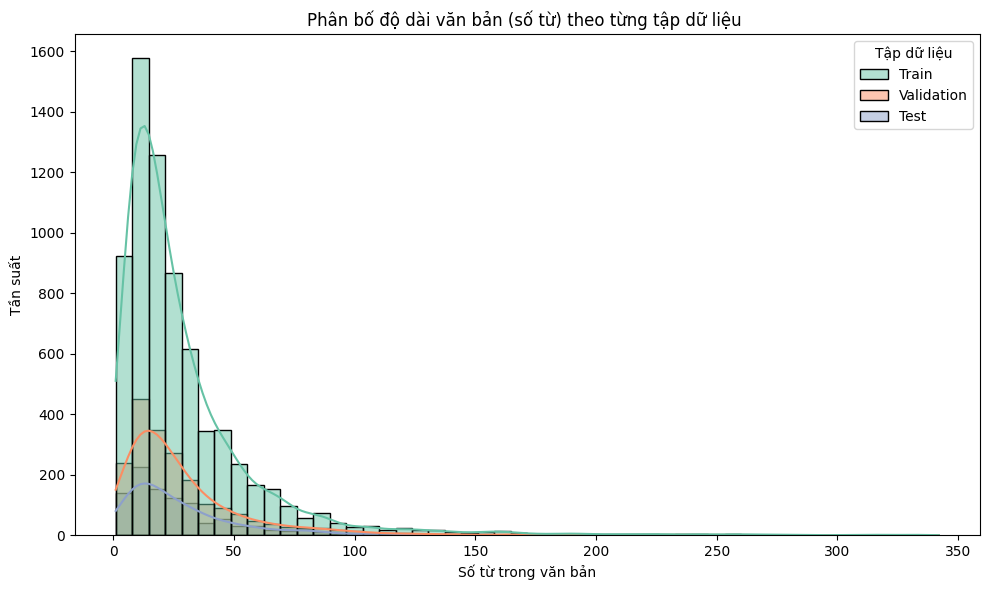

In [ ]:
# Sử dụng cột 'Comment' là nội dung văn bản
train_lengths = train_df['Comment'].astype(str).apply(lambda x: len(x.split()))
valid_lengths = valid_df['Comment'].astype(str).apply(lambda x: len(x.split()))
test_lengths = test_df['Comment'].astype(str).apply(lambda x: len(x.split()))

# Tạo DataFrame tổng hợp cho biểu đồ
lengths_df = pd.DataFrame({
    'Độ dài (số từ)': list(train_lengths) + list(valid_lengths) + list(test_lengths),
    'Tập dữ liệu': ['Train'] * len(train_lengths) + ['Validation'] * len(valid_lengths) + ['Test'] * len(test_lengths)
})

# Vẽ biểu đồ phân bố độ dài văn bản
plt.figure(figsize=(10, 6))
sns.histplot(
    data=lengths_df,
    x='Độ dài (số từ)',
    hue='Tập dữ liệu',
    bins=50,
    kde=True,
    palette='Set2'
)

# Giới hạn trục X để tập trung vào văn bản
# plt.xlim(0, 200)

# Thêm tiêu đề và nhãn trục
plt.title('Phân bố độ dài văn bản (số từ) theo từng tập dữ liệu ')
plt.xlabel('Số từ trong văn bản')
plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()


In [ ]:
# Lọc các câu có độ dài lớn hơn 150 từ trong cả 3 tập
train_over_150 = train_df[train_df['Comment'].apply(lambda x: len(x.split()) > 150)]
valid_over_150 = valid_df[valid_df['Comment'].apply(lambda x: len(x.split()) > 150)]
test_over_150 = test_df[test_df['Comment'].apply(lambda x: len(x.split()) > 150)]

# Gắn nhãn tập dữ liệu
train_over_150['Tập'] = 'Train'
valid_over_150['Tập'] = 'Validation'
test_over_150['Tập'] = 'Test'

# Gộp lại thành một bảng
long_comments_df = pd.concat([train_over_150, valid_over_150, test_over_150], ignore_index=True)

# Thêm cột độ dài
long_comments_df['Độ dài'] = long_comments_df['Comment'].astype(str).apply(lambda x: len(x.split()))

# Chọn các cột quan trọng để hiển thị
long_comments_summary = long_comments_df[['Tập', 'Độ dài', 'Comment']].sort_values(by='Tập', ascending=False)

count_by_set = long_comments_df['Tập'].value_counts().reset_index()
count_by_set.columns = ['Tập', 'Số lượng bình luận > 150 từ']
print(count_by_set)

long_comments_summary

          Tập  Số lượng bình luận > 150 từ
0       Train                           93
1  Validation                           27
2        Test                            6


/tmp/ipython-input-6-3734619296.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_over_150['Tập'] = 'Train'
/tmp/ipython-input-6-3734619296.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_over_150['Tập'] = 'Validation'
/tmp/ipython-input-6-3734619296.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

,Tập,Độ dài,Comment
100,Validation,322,"Tuyệt vời, chúc mừng các KS ĐH Bách khoa! Nhân..."
107,Validation,342,Cháu chào GS ạ!Cháu có con trai năm nay đang h...
93,Validation,168,Ta có công thức tính diện tích tam giác là (cạ...
94,Validation,161,Đọc qua một số ý kiến đọc giả về giảm xóc xe Q...
95,Validation,227,Nhớ lại kỷ niệm khi tôi là sinh viên đại học T...
...,...,...,...
121,Test,186,"Bám tới tận 20 năm cơ nhỉ,Nếu không phải Si ăn..."
122,Test,336,cho mọi người chưa hiểu hết về nội dung bộ phi...
123,Test,208,"Thực tế mà nói, không có cách nào có thể quản ..."
124,Test,180,Giảng dạy Công nghệ thông tin (CNTT) cho học s...


/tmp/ipython-input-7-590590819.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=train_df, x='Toxicity', palette='Set2')
/tmp/ipython-input-7-590590819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1, 0], data=train_df, x='Constructiveness', palette='Set2')
/tmp/ipython-input-7-590590819.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], data=valid_df, x='Toxicity', palette='Set2')
/tmp/ipython-input-7-590590819.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is d

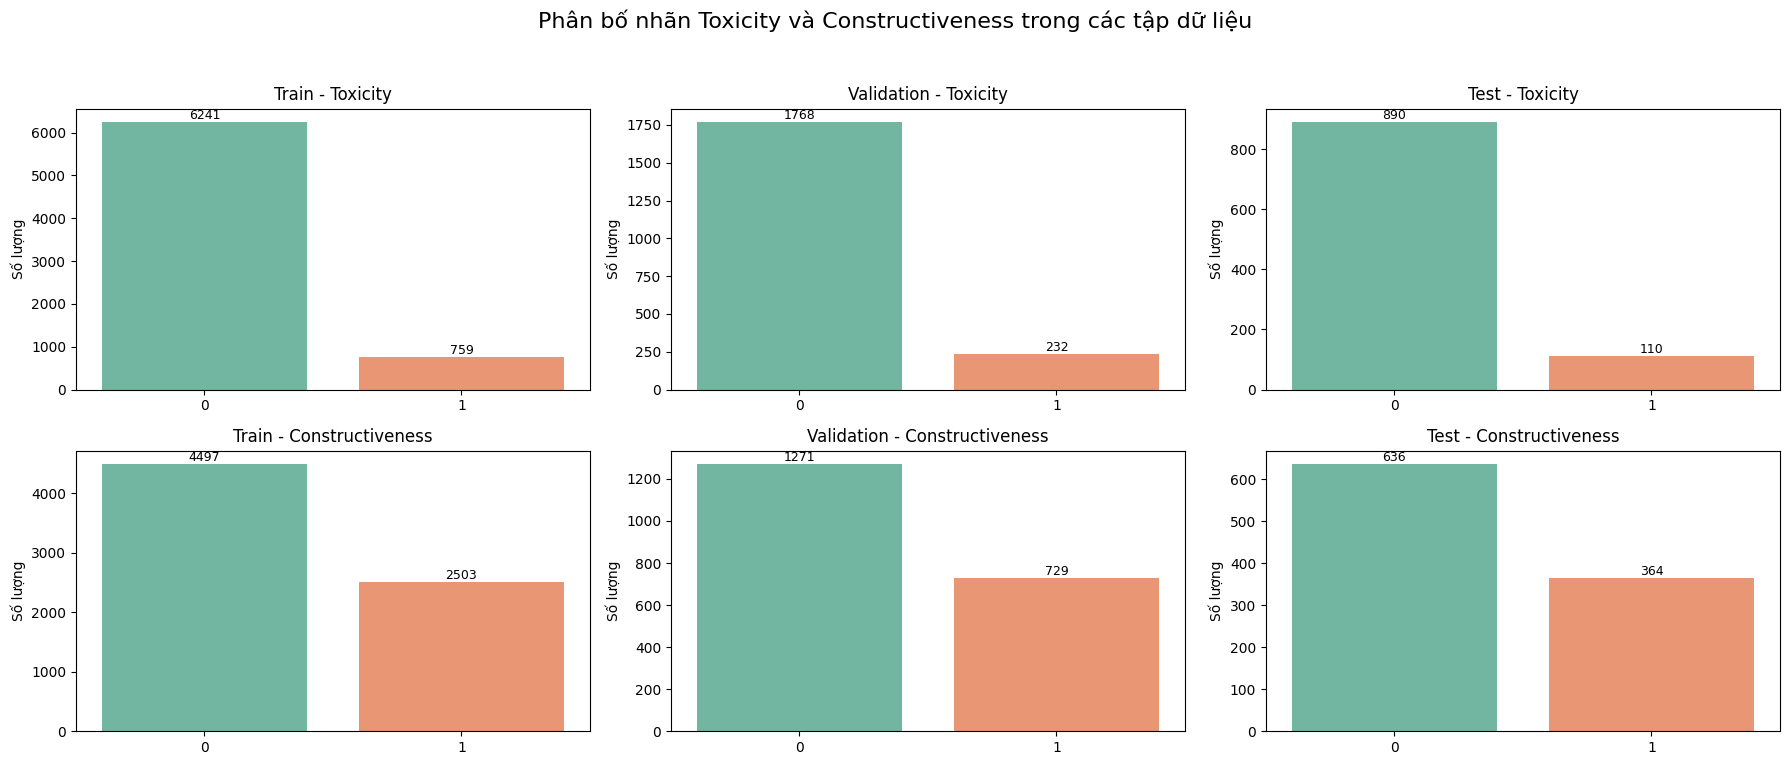

In [ ]:
# Hàm thêm số lượng trên mỗi cột
def add_value_labels(ax):
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2, height + 0.5,  # vị trí chữ
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Tạo figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Phân bố nhãn Toxicity và Constructiveness trong các tập dữ liệu", fontsize=16)

# Train
sns.countplot(ax=axes[0, 0], data=train_df, x='Toxicity', palette='Set2')
axes[0, 0].set_title('Train - Toxicity')
add_value_labels(axes[0, 0])

sns.countplot(ax=axes[1, 0], data=train_df, x='Constructiveness', palette='Set2')
axes[1, 0].set_title('Train - Constructiveness')
add_value_labels(axes[1, 0])

# Validation
sns.countplot(ax=axes[0, 1], data=valid_df, x='Toxicity', palette='Set2')
axes[0, 1].set_title('Validation - Toxicity')
add_value_labels(axes[0, 1])

sns.countplot(ax=axes[1, 1], data=valid_df, x='Constructiveness', palette='Set2')
axes[1, 1].set_title('Validation - Constructiveness')
add_value_labels(axes[1, 1])

# Test
sns.countplot(ax=axes[0, 2], data=test_df, x='Toxicity', palette='Set2')
axes[0, 2].set_title('Test - Toxicity')
add_value_labels(axes[0, 2])

sns.countplot(ax=axes[1, 2], data=test_df, x='Constructiveness', palette='Set2')
axes[1, 2].set_title('Test - Constructiveness')
add_value_labels(axes[1, 2])

# Căn chỉnh trục
for ax in axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

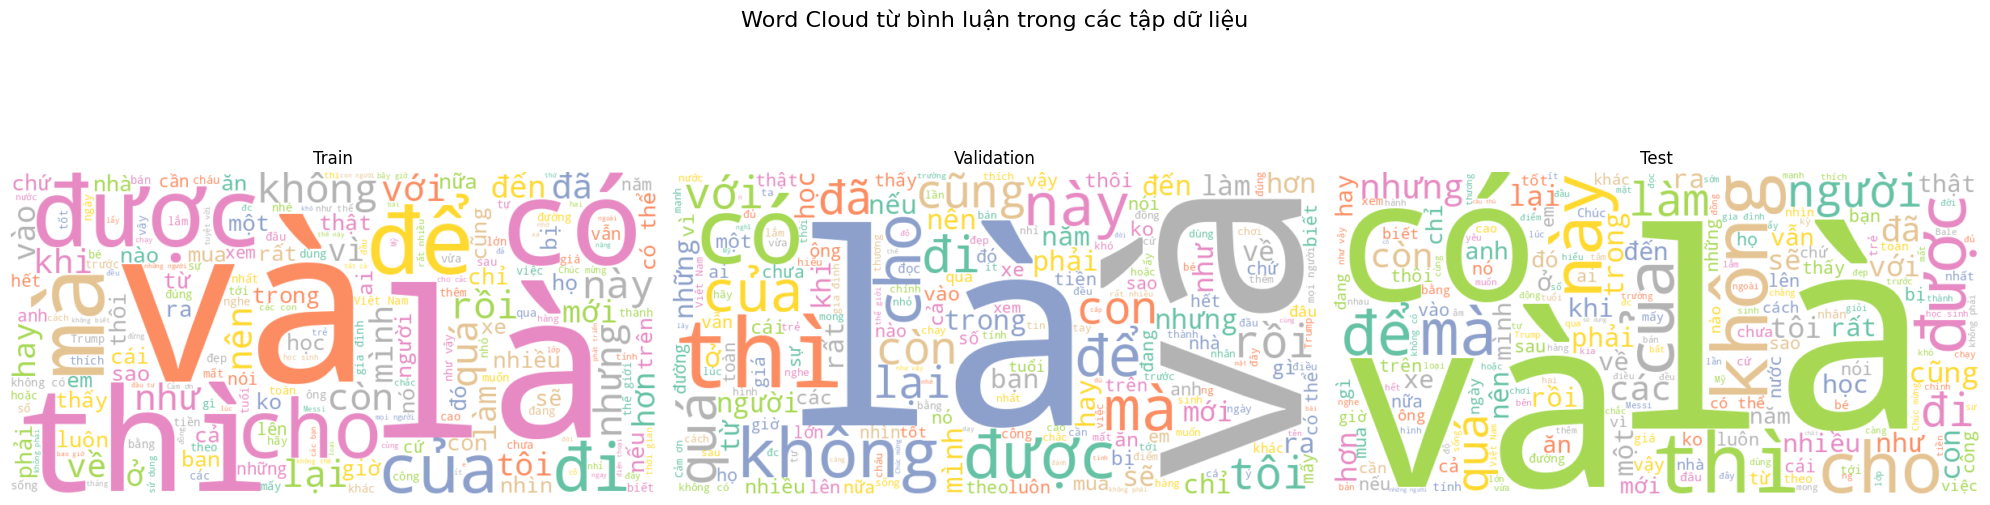

In [ ]:
# Word Cloud cho từng tập dữ liệu (Train, Validation, Test)
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Word Cloud từ bình luận trong các tập dữ liệu', fontsize=16)

# Train
text_train = " ".join(train_df['Comment'].astype(str))
wordcloud_train = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate(text_train)
axes[0].imshow(wordcloud_train, interpolation='bilinear')
axes[0].set_title("Train")
axes[0].axis("off")

# Validation
text_valid = " ".join(valid_df['Comment'].astype(str))
wordcloud_valid = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate(text_valid)
axes[1].imshow(wordcloud_valid, interpolation='bilinear')
axes[1].set_title("Validation")
axes[1].axis("off")

# Test
text_test = " ".join(test_df['Comment'].astype(str))
wordcloud_test = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate(text_test)
axes[2].imshow(wordcloud_test, interpolation='bilinear')
axes[2].set_title("Test")
axes[2].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


/tmp/ipython-input-9-130098287.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_train, y='Từ', x='Tần suất', ax=axes[0], palette='Set2')
/tmp/ipython-input-9-130098287.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_valid, y='Từ', x='Tần suất', ax=axes[1], palette='Set2')
/tmp/ipython-input-9-130098287.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_test, y='Từ', x='Tần suất', ax=axes[2], palette='Set2')


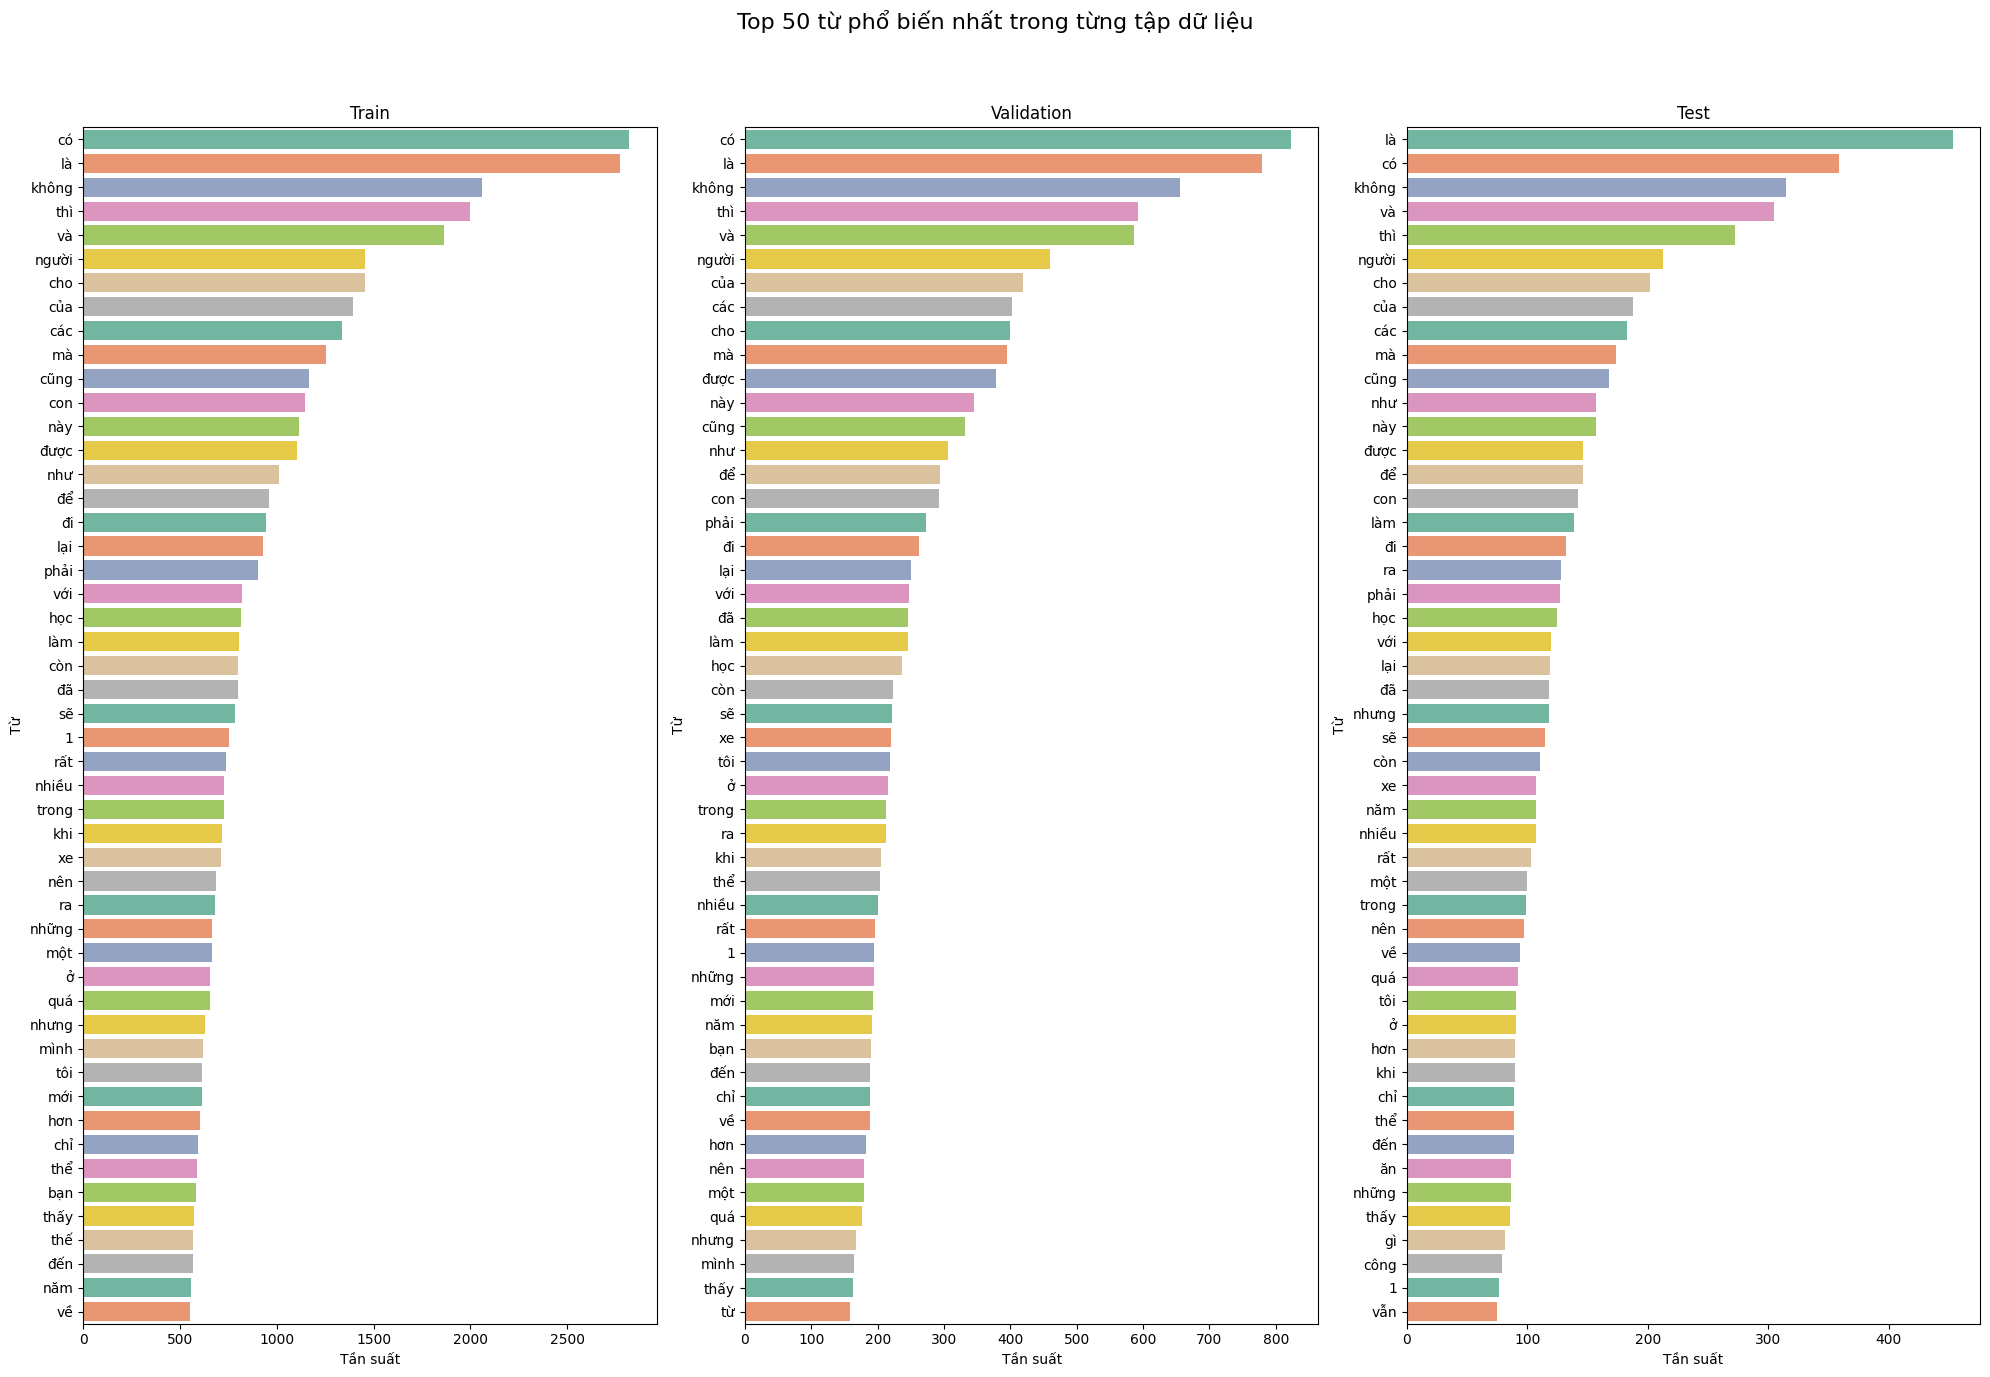

In [ ]:
# Barplot – Top 50 từ phổ biến nhất trong mỗi tập dữ liệu

from collections import Counter


fig, axes = plt.subplots(1, 3, figsize=(20, 14))
fig.suptitle('Top 50 từ phổ biến nhất trong từng tập dữ liệu', fontsize=16)

# Train
word_list_train = " ".join(train_df['Comment'].astype(str)).split()
top_words_train = pd.DataFrame(Counter(word_list_train).most_common(50), columns=['Từ', 'Tần suất'])
sns.barplot(data=top_words_train, y='Từ', x='Tần suất', ax=axes[0], palette='Set2')
axes[0].set_title("Train")

# Validation
word_list_valid = " ".join(valid_df['Comment'].astype(str)).split()
top_words_valid = pd.DataFrame(Counter(word_list_valid).most_common(50), columns=['Từ', 'Tần suất'])
sns.barplot(data=top_words_valid, y='Từ', x='Tần suất', ax=axes[1], palette='Set2')
axes[1].set_title("Validation")

# Test
word_list_test = " ".join(test_df['Comment'].astype(str)).split()
top_words_test = pd.DataFrame(Counter(word_list_test).most_common(50), columns=['Từ', 'Tần suất'])
sns.barplot(data=top_words_test, y='Từ', x='Tần suất', ax=axes[2], palette='Set2')
axes[2].set_title("Test")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


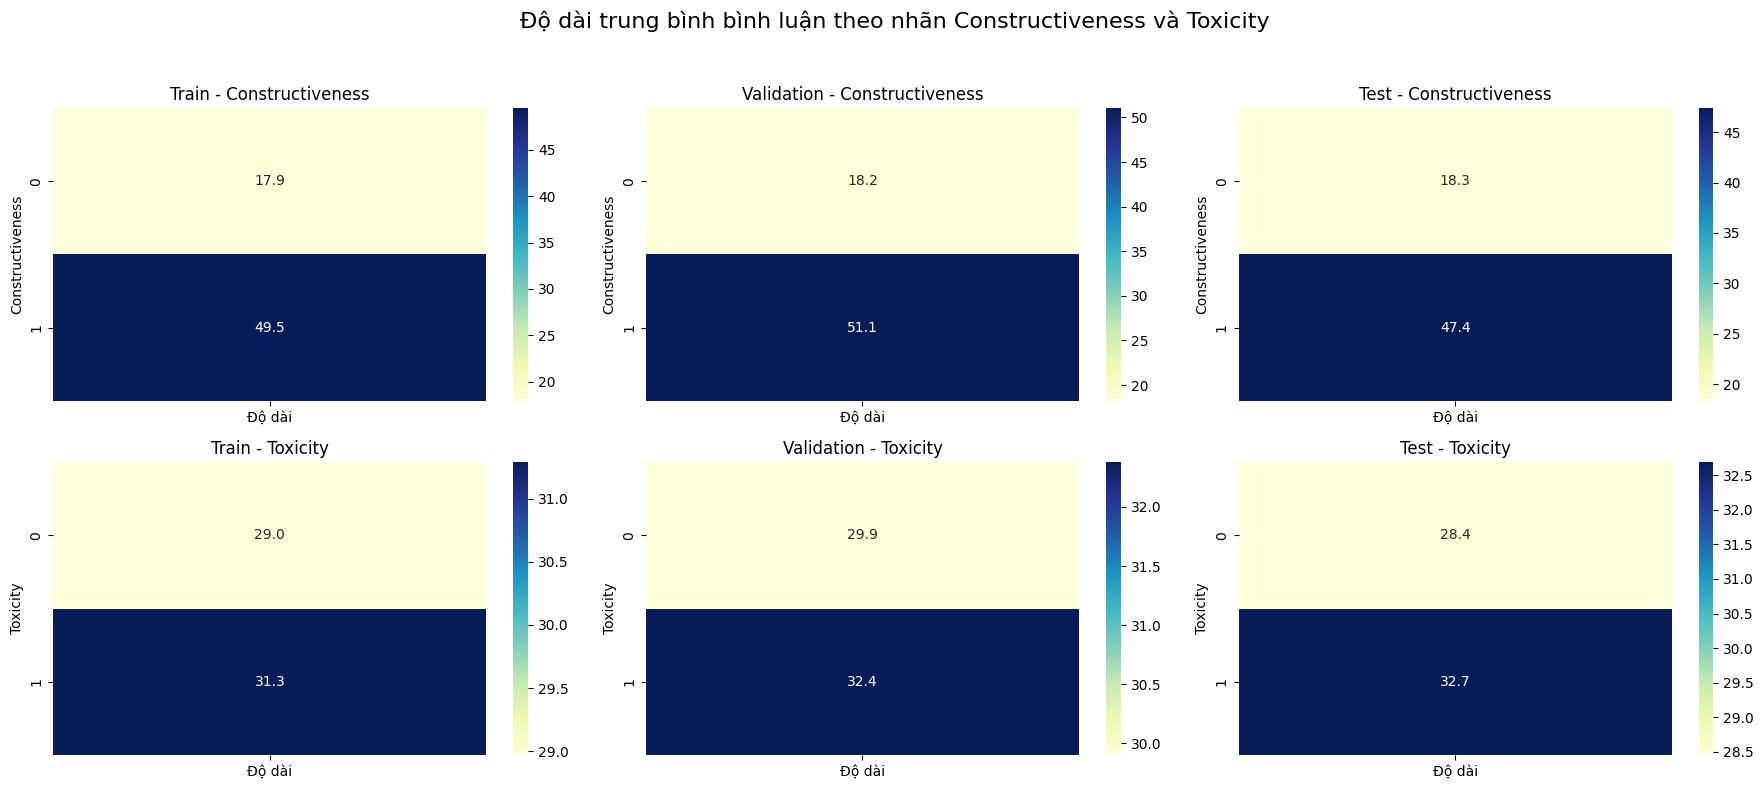

In [ ]:
# Heatmap – Độ dài trung bình bình luận theo nhãn Constructiveness và Toxicity trong từng tập

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Độ dài trung bình bình luận theo nhãn Constructiveness và Toxicity', fontsize=16)

# Thêm cột độ dài cho mỗi tập
train_df['Độ dài'] = train_df['Comment'].apply(lambda x: len(str(x).split()))
valid_df['Độ dài'] = valid_df['Comment'].apply(lambda x: len(str(x).split()))
test_df['Độ dài'] = test_df['Comment'].apply(lambda x: len(str(x).split()))

# Hàm vẽ heatmap độ dài trung bình theo nhãn
def plot_heatmap(data, by, ax, title):
    avg_len = data.groupby(by)['Độ dài'].mean().reset_index()
    if isinstance(by, list):
        heat_data = avg_len.pivot(index=by[0], columns=by[1], values='Độ dài')
    else:
        heat_data = avg_len.set_index(by)
    sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
    ax.set_title(title)

# Constructiveness
plot_heatmap(train_df, 'Constructiveness', axes[0, 0], 'Train - Constructiveness')
plot_heatmap(valid_df, 'Constructiveness', axes[0, 1], 'Validation - Constructiveness')
plot_heatmap(test_df, 'Constructiveness', axes[0, 2], 'Test - Constructiveness')

# Toxicity
plot_heatmap(train_df, 'Toxicity', axes[1, 0], 'Train - Toxicity')
plot_heatmap(valid_df, 'Toxicity', axes[1, 1], 'Validation - Toxicity')
plot_heatmap(test_df, 'Toxicity', axes[1, 2], 'Test - Toxicity')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Xử lý dữ liệu

In [ ]:
# 1. Chuẩn hóa Unicode
def normalize_unicode(text):
    return unicodedata.normalize('NFC', str(text))

# 2. Từ điển viết tắt
abbreviations = {
    "ko": "không", "k": "không", "khg": "không", "hok": "không",
    "dc": "được", "đc": "được", "vs": "với",
    "j": "gì", "z": "gì", "mik": "mình", "tl": "trả lời",
    "bít": "biết", "thjk": "thích", "hum": "hôm",
    "ck": "chồng", "vk": "vợ", "thui": "thôi", "bùn": "buồn", "e": "em",
    "bt": "biết", "r": "rồi", "ntn": "như thế nào", "m": "mình", "cx": "cũng",
    "ms": "mới", "mn": "mọi người", "ad": "admin"
}

def replace_abbreviations(text, abbr_dict):
    words = re.findall(r'\b\w+\b', str(text).lower())
    replaced = [abbr_dict.get(word, word) for word in words]
    return ' '.join(replaced)

# 3. Danh sách stopword tiếng Việt
stop_words = {
    "là", "có", "và", "của", "cho", "thì", "mà", "với", "đã", "đang",
    "từ", "trong", "ra", "vào", "đến", "đi", "vì", "trên", "rằng",
    "ơi", "dạ", "ơ", "ừ", "ừm"
}


# 4. Hàm tiền xử lý chính
def preprocess(text):
    if pd.isna(text):
        return ""
    text = normalize_unicode(text)
    text = replace_abbreviations(text, abbreviations)

    text = text.lower()  # Chuyển về chữ thường
    text = re.sub(r'[^\w\s]', '', text)  # Loại bỏ ký tự đặc biệt, giữ lại chữ và khoảng trắn

    tokens = word_tokenize(text, format='list')  # tách từ chuẩn
    filtered = [token for token in tokens if token not in stop_words]
    return ' '.join(filtered)  # ghép lại chuỗi cho TF-IDF



# 5. Tiền xử lý dữ liệu train và valid
train_df['processed'] = train_df['Comment'].apply(preprocess)
valid_df['processed'] = valid_df['Comment'].apply(preprocess)


In [ ]:
# In ra 20 ví dụ để kiểm tra quá trình tiền xử lý
train_df[['Comment','processed']].iloc[640:660]

,Comment,processed
640,Ác nhân ắt sẽ có ác báo!,ác nhân ắt sẽ ác báo
641,quan trọng mãnh đất bạn đang nói đến ai là ngư...,quan trọng mãnh đất bạn nói ai người đứng tên ...
642,55tr/m2 hấp dẫn thật,55 tr m2 hấp dẫn thật
643,Phân bón nổ như bom,phân bón nổ như bom
644,thương con quá. không biết sau này lớn lên và ...,thương con quá không biết sau này lớn lên biết...
645,"Mình không hiểu tại sao lại ko nhận ra được, k...",mình không hiểu tại sao lại không nhận được kh...
646,trừ khi làm ở TP lương cao hoặc có công việc ở...,trừ khi làm ở tp lương cao hoặc công việc ở đâ...
647,đây là sam biển đúng ko nhỉ,đây sam biển đúng không nhỉ
648,Năm đó tôi đóng thuế nhiều hơn tỷ phú Mỹ. Mà g...,năm đó tôi đóng thuế nhiều hơn tỷ phú mỹ giá b...
649,Chúc mừng việt nam .chúng ta cùng nhau chiến t...,chúc mừng việt nam chúng ta cùng nhau chiến th...


In [ ]:
# chuẩn bị dữ liệu đầu vào
X_train = train_df['processed']
X_valid = valid_df['processed']

y_train_toxicity = train_df['Toxicity']
y_valid_toxicity = valid_df['Toxicity']

y_train_constructive = train_df['Constructiveness']
y_valid_constructive = valid_df['Constructiveness']


# Vector hoá TF - IDF

## Lý thuyết:  **TF - IDF: Term Frequency - Inverse Document Frequency**
### 1. Tổng quan
TF-IDF (Term Frequency - Inverse Document Frequency) là một kỹ thuật phổ biến trong xử lý ngôn ngữ tự nhiên (NLP) dùng để **đánh giá mức độ quan trọng của một từ (hoặc cụm từ)** trong một văn bản (document) so với toàn bộ tập văn bản (corpus).

→ TF-IDF giúp máy tính hiểu rằng:
**Không phải từ nào xuất hiện nhiều cũng quan trọng** (ví dụ: “là”, “và”, “của”).

TF	   : nhấn mạnh từ xuất hiện nhiều trong 1 văn bản. <br>
IDF	   : giảm trọng số của các từ phổ biến, tăng trọng số cho từ hiếm. <br>
TF-IDF kết hợp cả 2: đo lường mức độ quan trọng thực sự của từ. <br>

### 2.  Thành phần cấu thành
 ***TF – Term Frequency***: tần suất của từ trong văn bản
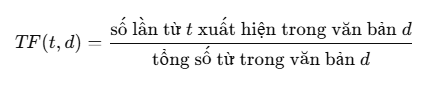

**Mục đích:** đo độ phổ biến của từ trong một văn bản

Ví dụ: "việt nam" xuất hiện 3 lần trong 100 từ → TF = 3/100 = 0.03

***IDF – Inverse Document Frequency***: tần suất ngược của từ trong toàn bộ tập văn bản

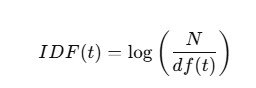

Trong đó:

N: tổng số văn bản trong tập dữ liệu

df(t): số văn bản chứa từ

Công thức dễ bị lỗi khi mà ***df(t) = 0*** nên trong scikit-learn công thức IDF sẽ có dạng

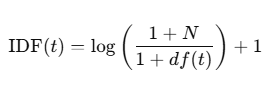

Đảm bảo IDF luôn > 0.

➡ Từ nào xuất hiện ở **nhiều văn bản** sẽ có **IDF thấp** <br>
➡ Từ nào **hiếm** sẽ có **IDF cao**

 ***TF-IDF = TF × IDF***

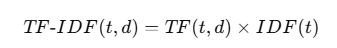

Từ nào xuất hiện nhiều trong văn bản và hiếm trong tập dữ liệu → điểm TF-IDF cao

Từ quá phổ biến trong cả tập dữ liệu → TF-IDF gần bằng 0



In [ ]:
#  Vector hóa TF-IDF

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df = 1)
X_tfidf = vectorizer.fit_transform(train_df['processed'])

# Hiển thị TF-IDF của 5 bình luận đầu tiên
feature_names = vectorizer.get_feature_names_out()
results = []

for i in range(100):
    row = X_tfidf[i]
    non_zero_idx = row.nonzero()[1]
    tfidf_vals = row.data

    tokens_weights = [
        (feature_names[idx], round(val, 4)) for idx, val in zip(non_zero_idx, tfidf_vals)
    ]

    results.append({
        "STT": i + 1,
        "Bình luận sau xử lý": train_df['processed'].iloc[i],
        "Vector TF-IDF (token → trọng số)": tokens_weights
    })

tfidf_df = pd.DataFrame(results)
tfidf_df

,STT,Bình luận sau xử lý,Vector TF-IDF (token → trọng số)
0,1,thật tuyệt vời,"[(thật, 0.3126), (tuyệt, 0.4194), (vời, 0.4533..."
1,2,mỹ tuột dốc quá nhiều rồi giờ muốn vực dậy cũn...,"[(mỹ, 0.1289), (tuột, 0.2386), (dốc, 0.2181), ..."
2,3,tôi thấy người lái xe hơi bấm còi mới người rấ...,"[(thật, 0.0512), (quá, 0.0879), (rất, 0.0487),..."
3,4,coi dịch giặc mang tên đó xâm nhập vn phải đầu...,"[(phải, 0.0683), (coi, 0.1207), (dịch, 0.0995)..."
4,5,thương các bé quá các con còn quá nhỏ phải sớm...,"[(thật, 0.067), (quá, 0.1151), (mới, 0.0656), ..."
...,...,...,...
95,96,kính chúc tổng thống trump mau bình phục đắc c...,"[(thống, 0.164), (nhiệm, 0.1648), (chúc, 0.128..."
96,97,không bán vàng chị vàng tăng 3 năm tới sẽ gấp ...,"[(sau, 0.0972), (đôi, 0.1392), (không, 0.0523)..."
97,98,nhiều khi mình vô tphcm mấy ngā tư muốn quẹo n...,"[(nhiều, 0.1347), (muốn, 0.1226), (rất, 0.1378..."
98,99,mục đích bảo hiểm bảo vệ mỗi năm bạn trích 10 ...,"[(rất, 0.0178), (khó, 0.0705), (rất khó, 0.033..."


IDF của các từ

In [ ]:
# Lấy IDF và từ/ngữ tương ứng
idf_values = vectorizer.idf_
feature_names = vectorizer.get_feature_names_out()

idf_df = pd.DataFrame({
    "Từ/ngữ (n-gram)": feature_names,
    "IDF": idf_values
})

# Sắp xếp theo độ hiếm (IDF cao nhất trước)
idf_df_sorted = idf_df.sort_values(by="IDF", ascending=False)
idf_df_sorted

,Từ/ngữ (n-gram),IDF
9,000 con,9.160661
96988,ực,9.160661
96987,ửng hộ,9.160661
1,00 18,9.160661
2,00 mối,9.160661
...,...,...
13765,các,2.888728
53918,này,2.734982
92016,được,2.733364
48286,người,2.671456


TF-IDF của các từ trong 1 câu cụ thể

In [ ]:
# Thay đổi số thứ tự ở đây để kiểm tra bình luận bất kỳ
n = 123

# Lấy bình luận thứ n
raw_comment = train_df['Comment'].iloc[n]
processed_comment = train_df['processed'].iloc[n]

print(f"📝 Bình luận gốc [{n}]:\n{raw_comment}\n")
print(f"✅ Sau xử lý:\n{processed_comment}\n")

#  Transform câu đã xử lý
X_vec = vectorizer.transform([processed_comment])

#  Lấy tên n-gram và trọng số TF-IDF
feature_names = vectorizer.get_feature_names_out()
vocab = vectorizer.vocabulary_
idf_dict = dict(zip(feature_names, vectorizer.idf_))

#  Tính TF từ văn bản đã xử lý
tokens = processed_comment.split()
tf_counts = {}
for token in tokens:
    tf_counts[token] = tf_counts.get(token, 0) + 1

# Thêm bigrams nếu có
for i in range(len(tokens) - 1):
    bigram = tokens[i] + " " + tokens[i + 1]
    tf_counts[bigram] = tf_counts.get(bigram, 0) + 1

total_terms = len(tokens)
tf_table_unigram = {k: v / total_terms for k, v in tf_counts.items()}

#  Kết hợp TF, IDF, TF-IDF
nonzero_indices = X_vec.nonzero()[1]
tfidf_values = X_vec.data

results = []
for idx, tfidf in zip(nonzero_indices, tfidf_values):
    term = feature_names[idx]
    idf = idf_dict.get(term, 0.0)

    if " " in term:  # bigram: suy ra TF từ TF-IDF
        tf = tfidf / idf if idf > 0 else 0.0
    else:  # unigram: dùng TF từ đếm
        tf = tf_table_unigram.get(term, 0.0)

    results.append({
        "Từ/ngữ (n-gram)": term,
        "TF": round(tf, 4),
        "IDF": round(idf, 4),
        "TF-IDF": round(tfidf, 4)
    })


# Hiển thị bảng kết quả
df_result = pd.DataFrame(results) #.sort_values(by="TF-IDF", ascending=False)

#  Sắp xếp theo thứ tự xuất hiện trong câu
ordered_terms = tokens[:]  # unigram
for i in range(len(tokens) - 1):
    bigram = tokens[i] + " " + tokens[i + 1]
    ordered_terms.append(bigram)

df_result['position'] = df_result['Từ/ngữ (n-gram)'].apply(
    lambda x: ordered_terms.index(x) if x in ordered_terms else float('inf')
)

df_result_ordered = df_result.sort_values(by='position').drop(columns='position')
df_result_ordered

📝 Bình luận gốc [123]:
Một cách giải quyết vấn đề rất hay. Vừa làm được việc nhà vừa thỏa đam mê và học được bài học kiếm tiền.

✅ Sau xử lý:
một cách giải quyết vấn đề rất hay vừa làm được việc nhà vừa thỏa đam mê học được bài học kiếm tiền



,Từ/ngữ (n-gram),TF,IDF,TF-IDF
17,một,0.0435,3.4018,0.0773
2,cách,0.0435,4.1368,0.0940
4,giải,0.0435,4.8040,0.1091
21,quyết,0.0435,5.2999,0.1204
30,vấn,0.0435,5.0747,0.1153
40,đề,0.0435,4.6068,0.1046
23,rất,0.0435,3.3157,0.0753
6,hay,0.0435,3.6472,0.0828
32,vừa,0.0870,4.7912,0.2177
13,làm,0.0435,3.2377,0.0735


In [ ]:
# 20 từ ích gặp nhất trong train
idf_scores = list(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))
idf_scores = sorted(idf_scores, key=lambda x: -x[1])  # sắp theo IDF cao nhất
print("🔍 Top 20 từ hiếm nhất trong vocab:")
print(idf_scores[:20])

🔍 Top 20 từ hiếm nhất trong vocab:
[('00 18', np.float64(9.160661094417252)), ('00 mối', np.float64(9.160661094417252)), ('00 xe', np.float64(9.160661094417252)), ('000 001', np.float64(9.160661094417252)), ('000 cad', np.float64(9.160661094417252)), ('000 chị', np.float64(9.160661094417252)), ('000 con', np.float64(9.160661094417252)), ('000 doanh', np.float64(9.160661094417252)), ('000 khán', np.float64(9.160661094417252)), ('000 km2', np.float64(9.160661094417252)), ('000 kể', np.float64(9.160661094417252)), ('000 lãi', np.float64(9.160661094417252)), ('000 lên', np.float64(9.160661094417252)), ('000 mm', np.float64(9.160661094417252)), ('000 nên', np.float64(9.160661094417252)), ('000 tiền', np.float64(9.160661094417252)), ('000 usd', np.float64(9.160661094417252)), ('000 đó', np.float64(9.160661094417252)), ('0000001', np.float64(9.160661094417252)), ('0000001 1020200002000000', np.float64(9.160661094417252))]


In [ ]:
# Lấy danh sách các n-gram (feature)
feature_names = vectorizer.get_feature_names_out()

# Hiển thị 100 n-gram đầu tiên
for i, feat in enumerate(feature_names[900:1000], 1):
    print(f"{i:>3}. {feat}")

  1. 35 bạn
  2. 35 khối
  3. 35 người
  4. 35 triệu
  5. 35 tuổi
  6. 350
  7. 350 000
  8. 350 còn
  9. 350 lên
 10. 3500
 11. 3500 cty
 12. 3500 tháng
 13. 355
 14. 355 tr
 15. 36
 16. 36 16
 17. 36 48
 18. 36 chết
 19. 36 năm
 20. 36 rồi
 21. 36 tiếng
 22. 36 triệu
 23. 36 tuổi
 24. 360
 25. 360 nhưng
 26. 360 này
 27. 370
 28. 370 000
 29. 370 400
 30. 378
 31. 378 cháu
 32. 39
 33. 39 2018
 34. 39999999
 35. 39999999 mm
 36. 3x5
 37. 3x5 15
 38. 40
 39. 40 50
 40. 40 cây
 41. 40 em
 42. 40 kim
 43. 40 kiến
 44. 40 m2
 45. 40 như
 46. 40 năm
 47. 40 nếu
 48. 40 phút
 49. 40 tuổi
 50. 40 vẫn
 51. 400
 52. 400 000
 53. 400 nhiều
 54. 400 tr
 55. 400 triệu
 56. 420
 57. 420 tiết
 58. 420 tr
 59. 420 triệu
 60. 430
 61. 430 tr
 62. 438
 63. 438 trận
 64. 44
 65. 45
 66. 45 46
 67. 45 cây
 68. 45 học
 69. 45 không
 70. 45 năm
 71. 45 phút
 72. 450
 73. 450 bàn
 74. 450 củ
 75. 450 hộ
 76. 45000
 77. 45000 thuộc
 78. 455
 79. 455 000
 80. 46
 81. 46 kg
 82. 46 triệu
 83. 476
 84. 476 hũ

# Chạy mô hình SVM


## Lý thuyết
### 1.Giới thiệu tổng quan:
SVM (Support Vector Machine) là một thuật toán học máy **có giám sát**, dùng để **phân loại** (classification) và **hồi quy** (regression), đặc biệt hiệu quả với dữ liệu **phân lớp rõ ràng.**

Trong đồ án này, SVM được áp dụng để phân loại các bình luận tiếng Việt theo các tiêu chí như:

Toxicity: bình luận độc hại hoặc không

Constructiveness: bình luận có mang tính xây dựng hay không

Dữ liệu đầu vào là các bình luận đã được chuyển thành vector bằng phương pháp TF-IDF. Với dữ liệu có số chiều lớn như vậy, SVM hoạt động hiệu quả nhờ khả năng xác định siêu phẳng phân tách tối ưu giữa các lớp.
### 2.Ý tưởng chính
SVM tìm ra **đường biên (hyperplane)** tốt nhất để** phân tách các điểm dữ liệu thuộc các lớp khác nhau.**

Trong không gian 2 chiều → đó là một đường thẳng

Trong không gian nhiều chiều → đó là một siêu phẳng (hyperplane) có dạng:

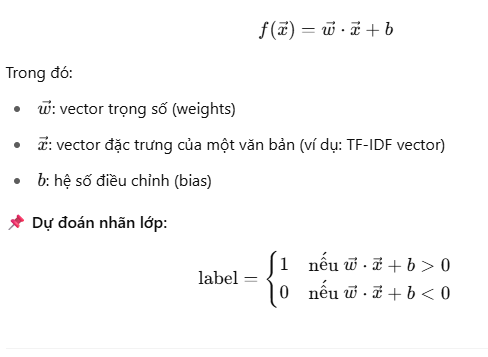

### 3. Hàm mục tiêu SVM( với SVM tuyến tính) dùng để tìm trọng số w

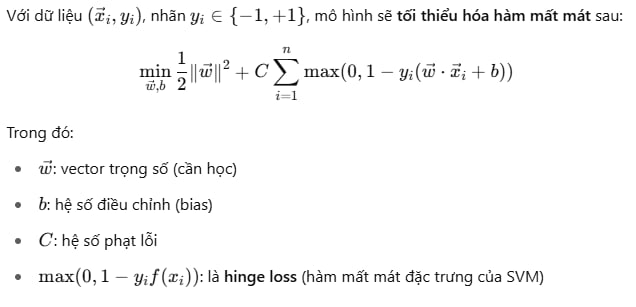

### 4.Quy trình
*Bước 1:* Chuyển câu thành vector số bằng TF-IDF

*Bước 2:* Đưa các vector này vào mô hình SVM (LinearSVC) để huấn luyện

*Bước 3:* Dự đoán nhãn văn bản mới bằng cách xem vector của nó nằm phía nào của đường phân chia



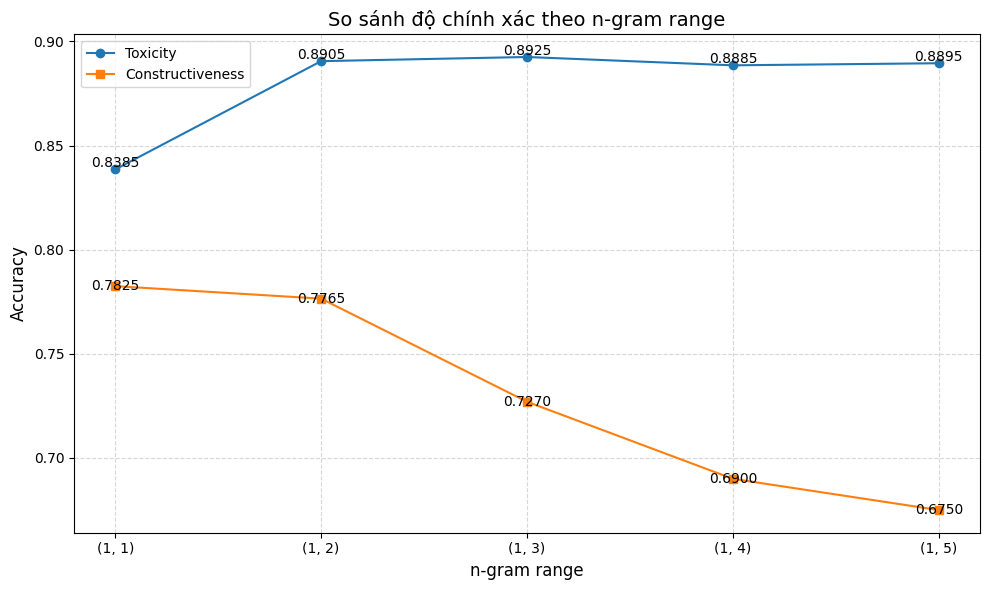

In [ ]:

# Các khoảng n-gram cần thử
ngram_ranges = [(1,1), (1,2), (1,3), (1,4), (1,5)]
ngram_labels = [str(n) for n in ngram_ranges]

# Khởi tạo danh sách độ chính xác
accuracy_toxicity = []
accuracy_constructive = []

# Huấn luyện mô hình cho từng n-gram range
for n in ngram_ranges:
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=n, min_df = 1)),
        ('clf', LinearSVC(C=1.0, class_weight='balanced', max_iter=1000))
    ])
    pipeline.fit(X_train, y_train_toxicity)
    y_pred_toxicity = pipeline.predict(X_valid)
    accuracy_toxicity.append(accuracy_score(y_valid_toxicity, y_pred_toxicity))


    pipeline.fit(X_train, y_train_constructive)
    y_pred_constructive = pipeline.predict(X_valid)
    accuracy_constructive.append(accuracy_score(y_valid_constructive, y_pred_constructive))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(ngram_labels, accuracy_toxicity, label='Toxicity', marker='o')
plt.plot(ngram_labels, accuracy_constructive, label='Constructiveness', marker='s')

for i in range(len(ngram_labels)):
    plt.text(i, accuracy_toxicity[i] + 0.001, f"{accuracy_toxicity[i]:.4f}", ha='center')
    plt.text(i, accuracy_constructive[i] - 0.002, f"{accuracy_constructive[i]:.4f}", ha='center')

plt.title("So sánh độ chính xác theo n-gram range", fontsize=14)
plt.xlabel("n-gram range", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

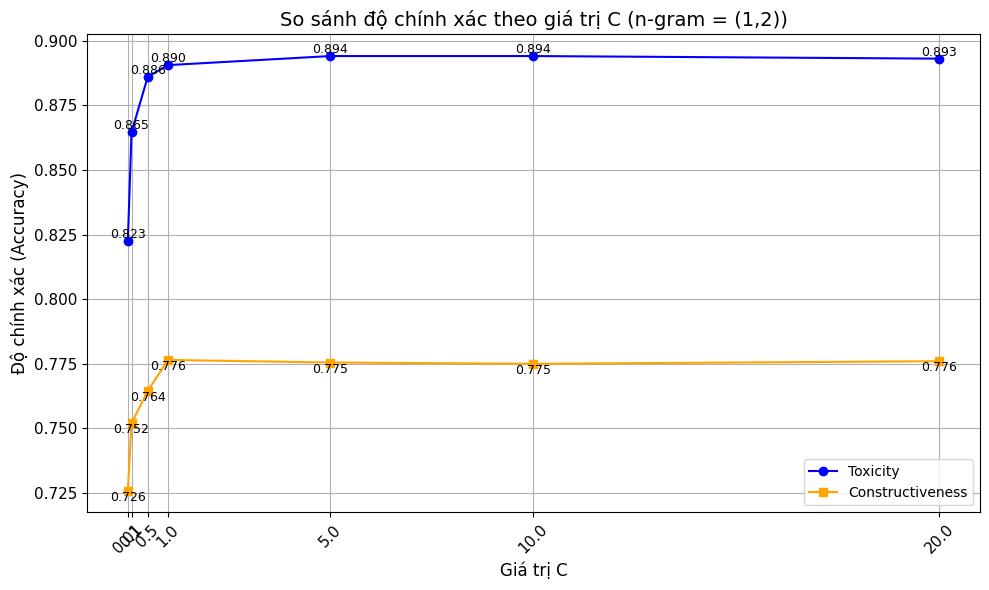

In [ ]:
# Giá trị C cần thử nghiệm
c_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0]
accuracy_toxicity = []
accuracy_constructive = []

# Huấn luyện và tính accuracy cho từng giá trị C
for c in c_values:
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ('clf', LinearSVC(C=c, class_weight='balanced', max_iter=1000))
    ])
    # Toxicity
    pipeline.fit(X_train, y_train_toxicity)
    y_pred_toxicity = pipeline.predict(X_valid)
    acc_toxic = accuracy_score(y_valid_toxicity, y_pred_toxicity)
    accuracy_toxicity.append(acc_toxic)

    # Constructiveness
    pipeline.fit(X_train, y_train_constructive)
    y_pred_constructive = pipeline.predict(X_valid)
    acc_constr = accuracy_score(y_valid_constructive, y_pred_constructive)
    accuracy_constructive.append(acc_constr)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 6))
plt.plot(c_values, accuracy_toxicity, marker='o', label='Toxicity', color='blue')
plt.plot(c_values, accuracy_constructive, marker='s', label='Constructiveness', color='orange')

# Annotate điểm
for i, acc in enumerate(accuracy_toxicity):
    plt.text(c_values[i], acc, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
for i, acc in enumerate(accuracy_constructive):
    plt.text(c_values[i], acc, f'{acc:.3f}', ha='center', va='top', fontsize=9)

# Thiết lập biểu đồ
plt.title('So sánh độ chính xác theo giá trị C (n-gram = (1,2))', fontsize=14)
plt.xlabel('Giá trị C', fontsize=12)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.xticks(c_values, [str(c) for c in c_values], rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.legend()
plt.tight_layout()

🔎 SVM Toxicity Validation:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1768
           1       0.54      0.38      0.45       232

    accuracy                           0.89      2000
   macro avg       0.73      0.67      0.69      2000
weighted avg       0.88      0.89      0.88      2000

Accuracy: 0.8905


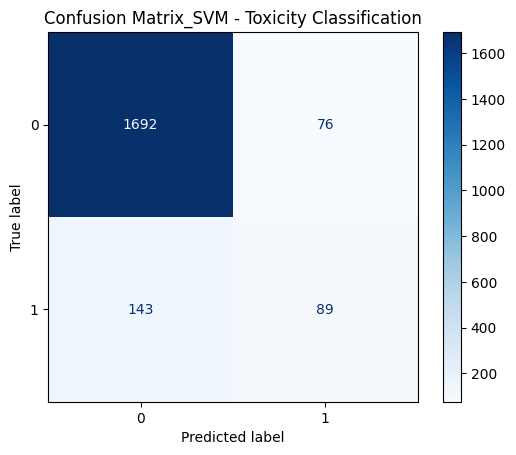

In [ ]:
# Pipeline SVM
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df = 1)),
    ('clf', LinearSVC(C=1.0, class_weight='balanced', max_iter=1000))
])

# Huấn luyện trên nhãn Toxicity
svm_pipeline.fit(X_train, y_train_toxicity)
y_pred_toxicity = svm_pipeline.predict(X_valid)
valid_df['predicted_toxicity'] = y_pred_toxicity

# Đánh giá
print("🔎 SVM Toxicity Validation:")
print(classification_report(y_valid_toxicity, y_pred_toxicity))
print("Accuracy:", accuracy_score(y_valid_toxicity, y_pred_toxicity))

# Tính và hiển thị ma trận nhầm lẫn
cm = confusion_matrix(y_valid_toxicity, y_pred_toxicity, labels=svm_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix_SVM - Toxicity Classification")
plt.show()


In [ ]:
# Lấy trọng số w và bias sau khi mô hình đã huấn luyện
clf = svm_pipeline.named_steps['clf']
vectorizer = svm_pipeline.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()

# Lấy trọng số w và bias b
w = clf.coef_[0]  # Vector trọng số cho SVM
b = clf.intercept_[0]  # Bias

# Tạo DataFrame để hiển thị rõ trọng số ứng với từng từ/ngram
weights_df = pd.DataFrame({
    "Từ/ngram": feature_names,
    "Trọng số SVM (w)": w
})

# Sắp xếp theo trọng số giảm dần để thấy các từ có ảnh hưởng mạnh nhất
weights_df_sorted = weights_df.sort_values(by="Trọng số SVM (w)", ascending=False).reset_index(drop=True)
print(b)
weights_df_sorted

-0.7524966051836404


,Từ/ngram,Trọng số SVM (w)
0,ác,2.446470
1,giết,2.063382
2,hát,1.681744
3,khốn,1.632696
4,chán,1.531233
...,...,...
96984,mới,-0.991630
96985,cá,-1.057007
96986,bão,-1.062888
96987,yêu,-1.079637


In [ ]:
# Lọc các câu bị phân loại sai
misclassified = valid_df[valid_df['Toxicity'] != valid_df['predicted_toxicity']]

# In một số câu sai
print("📌 Tổng số câu bị phân loại sai:", len(misclassified))
print("\n🔍 Một số ví dụ bị nhầm lẫn:")

for i, (index, row) in enumerate(misclassified.head(10).iterrows(), 1):
    print(f"\n❌ Câu bị sai thứ {i} (dòng gốc số {row['Unnamed: 0']}):")
    print("🗣 Nội dung:", row['Comment'])
    print(" Câu sau khi xử lý:", row['processed'])
    print("✅ Nhãn thực tế:", row['Toxicity'], "| ❌ Dự đoán:", row['predicted_toxicity'])

📌 Tổng số câu bị phân loại sai: 219

🔍 Một số ví dụ bị nhầm lẫn:

❌ Câu bị sai thứ 1 (dòng gốc số 6601):
🗣 Nội dung: Tội như thế này làm hại đến sức khỏe tính mạng con người ,phải có chế tài đủ mạnh để xử lý. Công ty làm phải có trách nhiệm sản phẩm mình làm ra , cứ làm bừa không kiểm soát được chất lượng sản phẩm rồi tung ra thị trường bán cho dân là không thể chấp nhận được
 Câu sau khi xử lý: tội như thế này làm hại sức khỏe tính mạng con người phải chế tài đủ mạnh để xử lý công ty làm phải trách nhiệm sản phẩm mình làm cứ làm bừa không kiểm soát được chất lượng sản phẩm rồi tung thị trường bán dân không thể chấp nhận được
✅ Nhãn thực tế: 1 | ❌ Dự đoán: 0

❌ Câu bị sai thứ 2 (dòng gốc số 3215):
🗣 Nội dung: Bánh truyền thống có thị phần của bánh truyền thống, bánh cách tân phục vụ giới trẻ và những người có nhu cầu khác truyền thống thì mới lấp được thị trường. Cứ bám vào truyền thống mãi không chịu cách tân đổi mới rồi bảo sao không thu hút được khách hàng.
 Câu sau khi xử lý: bánh 

In [ ]:

def get_tfidf_and_contributions_for_row(pipeline, df, text_column, row_id, id_column='Unnamed: 0'):
    """
    Trích xuất TF-IDF, trọng số SVM và đóng góp của từng từ/ngram cho một dòng cụ thể trong tập dữ liệu.

    Parameters:
        pipeline (Pipeline): Pipeline đã huấn luyện gồm 'tfidf' và 'clf'
        df (DataFrame): Tập dữ liệu validation
        text_column (str): Tên cột chứa văn bản đã xử lý (VD: 'processed')
        row_id (int): Giá trị trong cột id_column muốn xem TF-IDF
        id_column (str): Tên cột chứa ID gốc (VD: 'Unnamed: 0')

    Returns:
        DataFrame chứa các từ/ngram, TF-IDF, trọng số SVM và đóng góp
    """
    vectorizer = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()
    coefs = clf.coef_[0]  # Vector trọng số SVM
    bias = clf.intercept_[0]  # Bias

    # Vector hóa dữ liệu
    X_tfidf = vectorizer.transform(df[text_column])
    index_in_df = df[df[id_column] == row_id].index[0]
    row_vector = X_tfidf[index_in_df].tocoo()

    data = []
    score_sum = 0
    for i, v in zip(row_vector.col, row_vector.data):
        word = feature_names[i]
        weight = coefs[i]
        contribution = v * weight
        score_sum += contribution
        data.append((word, v, weight, contribution))

    # Tổng score cuối cùng
    total_score = score_sum + bias

    # Tạo DataFrame kết quả
    tfidf_df = pd.DataFrame(data, columns=["Từ/ngram", "Trọng số TF-IDF", "Trọng số SVM (w)", "Đóng góp (TF-IDF × w)"])
    tfidf_df = tfidf_df.sort_values(by="Đóng góp (TF-IDF × w)", ascending=False).reset_index(drop=True)

    original_text = df.loc[index_in_df, 'Comment'] if 'Comment' in df.columns else ""
    processed_text = df.loc[index_in_df, text_column]
    predicted_label = df.loc[index_in_df, 'predicted_toxicity'] if 'predicted_toxicity' in df.columns else "Không có"
    true_label = df.loc[index_in_df, 'Toxicity'] if 'Toxicity' in df.columns else "Không có"

    print(f"📝 Văn bản gốc: {original_text}")
    print(f"🔧 Văn bản đã xử lý: {processed_text}")
    print(f"✅ Nhãn thực tế: {true_label} | ❌ Nhãn dự đoán: {predicted_label}")
    print(f"⚖️  Bias (intercept): {bias:.4f}")
    print(f"📊 Tổng điểm (∑TF-IDF × w + bias): {total_score:.4f}\n")

    return tfidf_df


In [ ]:
tfidf_result = get_tfidf_and_contributions_for_row(
    pipeline=svm_pipeline,
    df=valid_df,
    text_column='processed',
    row_id=5017
)

print(tfidf_result)

📝 Văn bản gốc: Quán karaoke này không dẹp thì còn tội phạm dài dài
🔧 Văn bản đã xử lý: quán karaoke này không dẹp còn tội phạm dài dài
✅ Nhãn thực tế: 0 | ❌ Nhãn dự đoán: 1
⚖️  Bias (intercept): -0.7525
📊 Tổng điểm (∑TF-IDF × w + bias): 0.1375

        Từ/ngram  Trọng số TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
0            dẹp         0.311440          0.788030               0.245424
1       tội phạm         0.287198          0.573308               0.164653
2            tội         0.198665          0.742690               0.147546
3            này         0.112801          1.018644               0.114904
4           phạm         0.241887          0.382898               0.092618
5            còn         0.130146          0.667383               0.086857
6      này không         0.234240          0.293242               0.068689
7            dài         0.424338          0.152678               0.064787
8          không         0.089194          0.557595               0.049734
9    

                                             Comment  Predicted_Toxicity
0                 Người ăn không hết kẻ lần chẳng ra                   1
1    Nhiều người cứ nghĩ đạp xe là văn minh. haizzzz                   0
2                                        Rất văn hoá                   0
3  Đời ta ba mươi đời nó. Mua chiếc xe cũng chỉ p...                   0
4  Tước bằng lái vĩnh viễn đi. Chạy lếu láo thật,...                   1
📊 [Toxicity] Test Accuracy: 0.895
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       890
           1       0.53      0.42      0.47       110

    accuracy                           0.90      1000
   macro avg       0.73      0.69      0.70      1000
weighted avg       0.89      0.90      0.89      1000



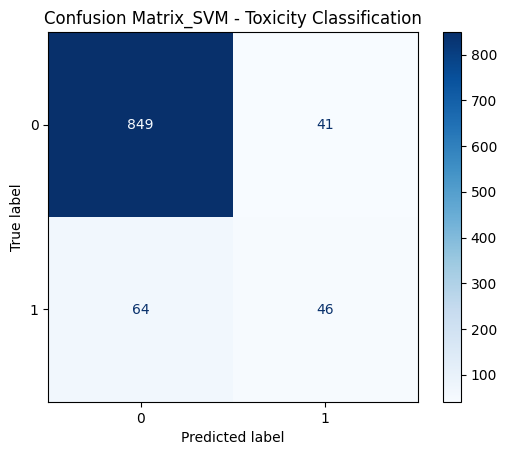

In [ ]:
# Tiền xử lý bình luận trong tập test
X_test = test_df['Comment'].apply(preprocess)

# Dự đoán
y_test_pred_svm_toxicity = svm_pipeline.predict(X_test)
y_test_toxicity = test_df['Toxicity']
# Gắn kết quả vào DataFrame
test_df['Predicted_Toxicity'] = y_test_pred_svm_toxicity

# Đánh giá
print(test_df[['Comment', 'Predicted_Toxicity']].head())
print("📊 [Toxicity] Test Accuracy:", accuracy_score(test_df['Toxicity'], test_df['Predicted_Toxicity']))
print(classification_report(test_df['Toxicity'], test_df['Predicted_Toxicity']))

cm = confusion_matrix(y_test_toxicity, y_test_pred_svm_toxicity, labels=svm_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix_SVM - Toxicity Classification")
plt.show()


🔎 SVM Constructiveness Validation:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1271
           1       0.66      0.81      0.73       729

    accuracy                           0.78      2000
   macro avg       0.77      0.78      0.77      2000
weighted avg       0.79      0.78      0.78      2000

Accuracy: 0.7765


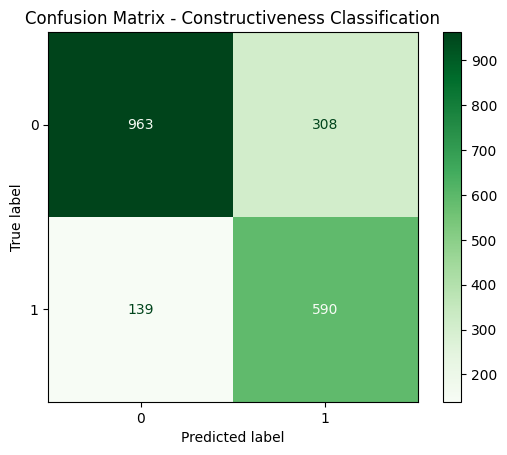

In [ ]:
# Huấn luyện SVM trên nhãn Constructiveness
svm_pipeline.fit(X_train, y_train_constructive)
y_pred_constructive = svm_pipeline.predict(X_valid)
valid_df['predicted_constructive'] = y_pred_constructive

# Đánh giá
print("🔎 SVM Constructiveness Validation:")
print(classification_report(y_valid_constructive, y_pred_constructive))
print("Accuracy:", accuracy_score(y_valid_constructive, y_pred_constructive))

# Tính và hiển thị ma trận nhầm lẫn cho Constructiveness
cm = confusion_matrix(y_valid_constructive, y_pred_constructive, labels=svm_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_pipeline.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Constructiveness Classification")
plt.show()

In [ ]:
# Lấy trọng số w và bias sau khi mô hình đã huấn luyện
clf = svm_pipeline.named_steps['clf']
vectorizer = svm_pipeline.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()

# Lấy trọng số w và bias b
w = clf.coef_[0]  # Vector trọng số cho SVM
b = clf.intercept_[0]  # Bias

# Tạo DataFrame để hiển thị rõ trọng số ứng với từng từ/ngram
weights_df = pd.DataFrame({
    "Từ/ngram": feature_names,
    "Trọng số SVM (w)": w
})

# Sắp xếp theo trọng số giảm dần để thấy các từ có ảnh hưởng mạnh nhất
weights_df_sorted = weights_df.sort_values(by="Trọng số SVM (w)", ascending=False).reset_index(drop=True)
print(b)
weights_df_sorted

-1.0967583866789947


,Từ/ngram,Trọng số SVM (w)
0,fadil,2.608339
1,xe,2.277102
2,bale,2.266435
3,nên,2.119260
4,những,1.962587
...,...,...
96984,mèo,-0.827247
96985,tôi sẽ,-0.846546
96986,thật,-0.851485
96987,quá nguy,-0.898363


In [ ]:
# Lọc các câu bị phân loại sai cho nhãn Constructiveness
misclassified_constructive = valid_df[valid_df['Constructiveness'] != valid_df['predicted_constructive']]

# In thông tin tổng quan và một số ví dụ bị phân loại sai
print("📌 Tổng số câu bị phân loại sai (Constructiveness):", len(misclassified_constructive))
print("\n🔍 Một số ví dụ bị nhầm lẫn:")

for i, (index, row) in enumerate(misclassified_constructive.head(10).iterrows(), 1):
    print(f"\n❌ Câu bị sai thứ {i} (dòng gốc số {row['Unnamed: 0']}):")
    print("🗣 Nội dung:", row['Comment'])
    print("🔧 Câu sau khi xử lý:", row['processed'])
    print("✅ Nhãn thực tế:", row['Constructiveness'], "| ❌ Dự đoán:", row['predicted_constructive'])


📌 Tổng số câu bị phân loại sai (Constructiveness): 447

🔍 Một số ví dụ bị nhầm lẫn:

❌ Câu bị sai thứ 1 (dòng gốc số 7218):
🗣 Nội dung: Cuộc bầu cư người đứng đầu Quốc gia ở Mỹ là công khai và công bằng nhất, chính vì vậy đến khi có kết quả chính thức mới biết được người dân họ bầu cho ai.
🔧 Câu sau khi xử lý: cuộc bầu cư người đứng đầu quốc gia ở mỹ công khai công bằng nhất chính vì vậy khi kết quả chính thức mới biết được người dân họ bầu ai
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu bị sai thứ 2 (dòng gốc số 5360):
🗣 Nội dung: Hoan hô sự quả cảm của các chiến sĩ và sự đồng lòng của các anh em lái xe đường dài và người dân xung quanh.
🔧 Câu sau khi xử lý: hoan hô sự quả cảm các chiến sĩ sự đồng lòng các anh em lái xe đường dài người dân xung quanh
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu bị sai thứ 3 (dòng gốc số 1397):
🗣 Nội dung: Người ở vị trí cuối cùng có lợi thế hơn những người còn lại.
🔧 Câu sau khi xử lý: người ở vị trí cuối cùng lợi thế hơn những người còn lại
✅ Nhãn thực tế: 0 |

In [ ]:


def get_tfidf_and_contributions_for_row_constructive(pipeline, df, text_column, row_id, id_column='Unnamed: 0'):
    """
    Trích xuất TF-IDF, trọng số SVM và đóng góp của từng từ/ngram cho một dòng cụ thể trong tập dữ liệu
    với nhãn Constructiveness.

    Parameters:
        pipeline (Pipeline): Pipeline đã huấn luyện gồm 'tfidf' và 'clf'
        df (DataFrame): Tập dữ liệu validation
        text_column (str): Tên cột chứa văn bản đã xử lý (VD: 'processed')
        row_id (int): Giá trị trong cột id_column muốn xem TF-IDF
        id_column (str): Tên cột chứa ID gốc (VD: 'Unnamed: 0')

    Returns:
        DataFrame chứa các từ/ngram, TF-IDF, trọng số SVM và đóng góp
    """
    vectorizer = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()
    coefs = clf.coef_[0]
    bias = clf.intercept_[0]

    # Biến đổi dữ liệu
    X_tfidf = vectorizer.transform(df[text_column])
    index_in_df = df[df[id_column] == row_id].index[0]
    row_vector = X_tfidf[index_in_df].tocoo()

    data = []
    score_sum = 0
    for i, v in zip(row_vector.col, row_vector.data):
        word = feature_names[i]
        weight = coefs[i]
        contribution = v * weight
        score_sum += contribution
        data.append((word, v, weight, contribution))

    total_score = score_sum + bias

    tfidf_df = pd.DataFrame(data, columns=["Từ/ngram", "Trọng số TF-IDF", "Trọng số SVM (w)", "Đóng góp (TF-IDF × w)"])
    tfidf_df = tfidf_df.sort_values(by="Đóng góp (TF-IDF × w)", ascending=False).reset_index(drop=True)

    # Lấy nội dung văn bản và nhãn
    original_text = df.loc[index_in_df, 'Comment'] if 'Comment' in df.columns else ""
    processed_text = df.loc[index_in_df, text_column]
    predicted_label = df.loc[index_in_df, 'predicted_constructive'] if 'predicted_constructive' in df.columns else "Không có"
    true_label = df.loc[index_in_df, 'Constructiveness'] if 'Constructiveness' in df.columns else "Không có"

    print(f"📝 Văn bản gốc: {original_text}")
    print(f"🔧 Văn bản đã xử lý: {processed_text}")
    print(f"✅ Nhãn thực tế: {true_label} | ❌ Nhãn dự đoán: {predicted_label}")
    print(f"⚖️  Bias (intercept): {bias:.4f}")
    print(f"📊 Tổng điểm (∑TF-IDF × w + bias): {total_score:.4f}\n")

    return tfidf_df


In [ ]:
# Ví dụ: lấy TF-IDF và đóng góp cho dòng có id 3212
result = get_tfidf_and_contributions_for_row_constructive(
    pipeline=svm_pipeline,
    df=valid_df,
    text_column='processed',
    row_id=9729
)
print(result)

📝 Văn bản gốc: cuộc sống tuy khó khăn nhưng lớn lên trong hoàn cảnh khó khăn vậy đc cái là tự lập từ bé, mạnh mẽ
🔧 Văn bản đã xử lý: cuộc sống tuy khó khăn nhưng lớn lên hoàn cảnh khó khăn vậy được cái tự lập bé mạnh mẽ
✅ Nhãn thực tế: 1 | ❌ Nhãn dự đoán: 0
⚖️  Bias (intercept): -1.0968
📊 Tổng điểm (∑TF-IDF × w + bias): -0.0382

      Từ/ngram  Trọng số TF-IDF  Trọng số SVM (w)  Đóng góp (TF-IDF × w)
0        nhưng         0.092089          1.936736               0.178352
1          khó         0.241643          0.640756               0.154834
2         sống         0.118931          1.135049               0.134992
3          lập         0.174013          0.677142               0.117832
4          tuy         0.155261          0.689955               0.107123
5         được         0.075517          1.015325               0.076674
6          lớn         0.115784          0.661306               0.076569
7           bé         0.120707          0.422965               0.051055
8           

                                             Comment  \
0                 Người ăn không hết kẻ lần chẳng ra   
1    Nhiều người cứ nghĩ đạp xe là văn minh. haizzzz   
2                                        Rất văn hoá   
3  Đời ta ba mươi đời nó. Mua chiếc xe cũng chỉ p...   
4  Tước bằng lái vĩnh viễn đi. Chạy lếu láo thật,...   

   Predicted_svm_Constructiveness  
0                               0  
1                               0  
2                               0  
3                               1  
4                               1  
📊 [Constructiveness] Test Accuracy: 0.794
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       636
           1       0.67      0.87      0.75       364

    accuracy                           0.79      1000
   macro avg       0.79      0.81      0.79      1000
weighted avg       0.82      0.79      0.80      1000



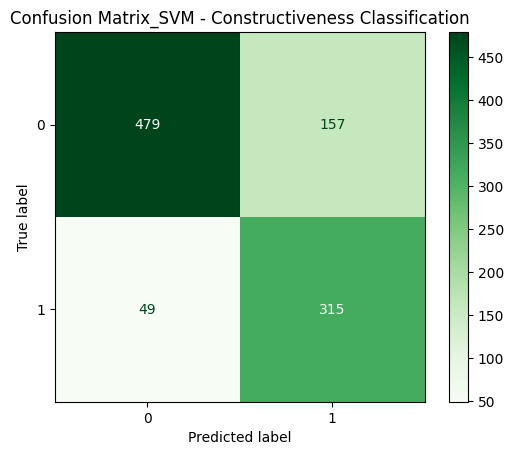

In [ ]:
# Dự đoán
y_test_pred_svm_constructive = svm_pipeline.predict(X_test)
y_test_constructive = test_df['Constructiveness']
# Gắn kết quả
test_df['Predicted_svm_Constructiveness'] = y_test_pred_svm_constructive

# Đánh giá
print(test_df[['Comment', 'Predicted_svm_Constructiveness']].head())
print("📊 [Constructiveness] Test Accuracy:", accuracy_score(test_df['Constructiveness'], test_df['Predicted_svm_Constructiveness']))
print(classification_report(test_df['Constructiveness'], test_df['Predicted_svm_Constructiveness']))

# Tính và hiển thị ma trận nhầm lẫn cho Constructiveness
cm = confusion_matrix(y_test_constructive, y_test_pred_svm_constructive, labels=svm_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_pipeline.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix_SVM - Constructiveness Classification")
plt.show()

#  Logistic Regression


### 1. Mục tiêu mô hình
Logistic Regression là một mô hình phân loại nhị phân, thường được sử dụng để dự đoán xem một đối tượng thuộc về lớp 1 hay lớp 0.
Trong đồ án, mô hình này được dùng để phân loại các bình luận thành:

Toxic (độc hại) hoặc Non-toxic (không độc hại)

Constructive (xây dựng) hoặc Non-constructive (không xây dựng)
### 2. Hàm dự đoán (Hypothesis)

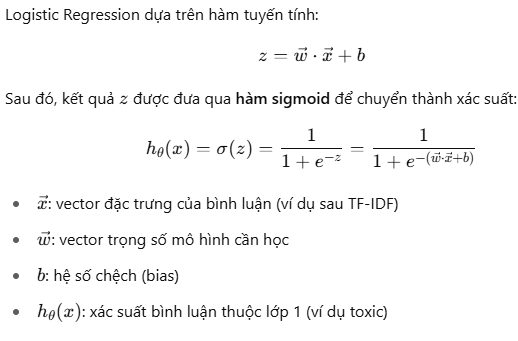

### 3 Hàm mất mát
### 1. Mục tiêu mô hình
Logistic Regression là một mô hình phân loại nhị phân, thường được sử dụng để dự đoán xem một đối tượng thuộc về lớp 1 hay lớp 0.
Trong đồ án, mô hình này được dùng để phân loại các bình luận thành:

Toxic (độc hại) hoặc Non-toxic (không độc hại)

Constructive (xây dựng) hoặc Non-constructive (không xây dựng)
### 2. Hàm dự đoán (Hypothesis)

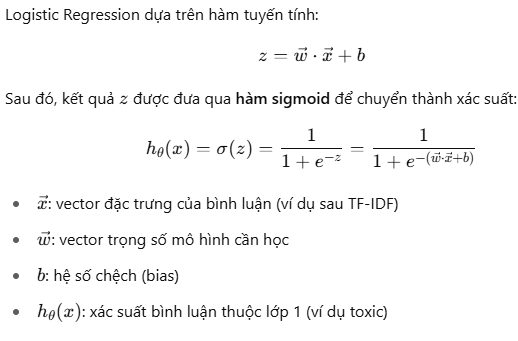

### 3 Hàm mất mát
Để học được các trọng số phù hợp, Logistic Regression sử dụng hàm mất mát log-loss (cross-entropy) như sau:
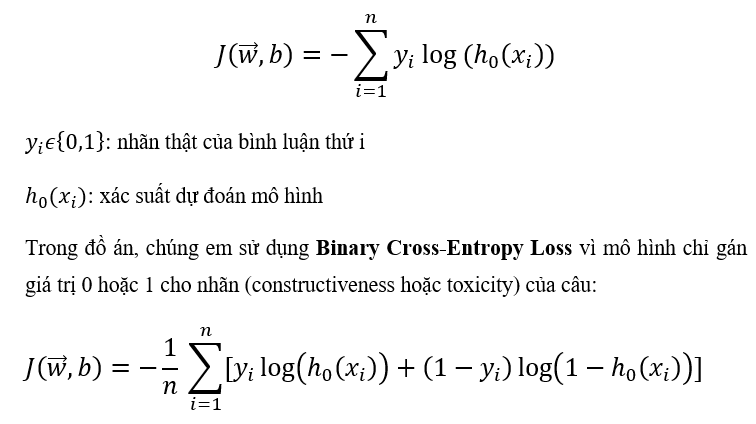

→ Mục tiêu của huấn luyện là tối thiểu hóa hàm mất mát này.

→ Hàm mất mát càng nhỏ ⇒ mô hình càng khớp dữ liệu

### 4. Dự đoán nhãn

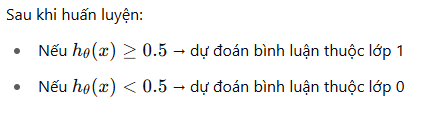

🔎 Logistic Regression - Toxicity:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      1768
           1       0.43      0.56      0.48       232

    accuracy                           0.86      2000
   macro avg       0.68      0.73      0.70      2000
weighted avg       0.88      0.86      0.87      2000

Accuracy: 0.863


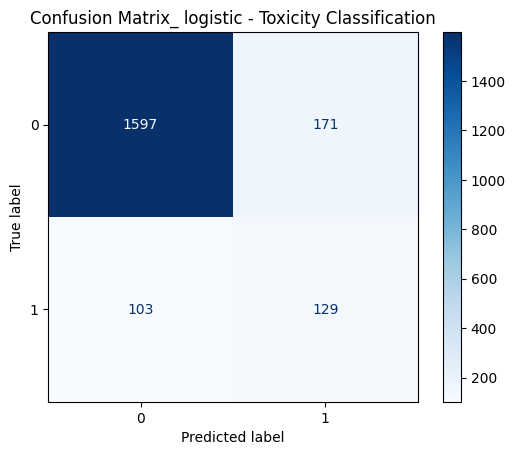

In [ ]:
# Pipeline Logistic Regression
logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Toxicity
logistic_pipeline.fit(X_train, y_train_toxicity)
y_pred_logistic_toxic = logistic_pipeline.predict(X_valid)
valid_df['predicted_logistic_toxicity'] = y_pred_logistic_toxic

print("🔎 Logistic Regression - Toxicity:")
print(classification_report(y_valid_toxicity, y_pred_logistic_toxic))
print("Accuracy:", accuracy_score(y_valid_toxicity, y_pred_logistic_toxic))


# 🧩 Ma trận nhầm lẫn
cm = confusion_matrix(y_valid_toxicity, y_pred_logistic_toxic, labels=logistic_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix_ logistic - Toxicity Classification")
plt.show()


In [ ]:
# 🔍 Trích xuất mô hình và vectorizer từ pipeline
clf = logistic_pipeline.named_steps['clf']
vectorizer = logistic_pipeline.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()

# 📌 Lấy trọng số w và bias b
w = clf.coef_[0]        # Vector trọng số
b = clf.intercept_[0]   # Bias (intercept)

# 📊 Tạo DataFrame hiển thị trọng số của từng từ/ngram
weights_df = pd.DataFrame({
    "Từ/ngram": feature_names,
    "Trọng số Logistic (w)": w
})

# 🔽 Sắp xếp theo độ ảnh hưởng giảm dần
weights_df_sorted = weights_df.sort_values(by="Trọng số Logistic (w)", ascending=False).reset_index(drop=True)

# 📥 In bias và bảng trọng số
print("⚖️ Bias (intercept):", b)
weights_df_sorted


⚖️ Bias (intercept): -0.9678003814615223


,Từ/ngram,Trọng số Logistic (w)
0,ác,3.934109
1,người,3.271130
2,giết,2.578584
3,hát,2.485279
4,này,2.463307
...,...,...
96984,tuyệt,-1.793780
96985,bão,-1.797884
96986,cá,-2.154352
96987,sẽ,-2.245303


In [ ]:
# Lọc các câu bị phân loại sai
misclassified_toxicity_logistic = valid_df[valid_df['Toxicity'] != valid_df['predicted_logistic_toxicity']]

# In một số câu sai
print("📌 Tổng số câu bị phân loại sai:", len(misclassified_toxicity_logistic))
print("\n🔍 Một số ví dụ bị nhầm lẫn:")

for i, (index, row) in enumerate(misclassified_toxicity_logistic.head(10).iterrows(), 1):
    print(f"\n❌ Câu bị sai thứ {i} (dòng gốc số {row['Unnamed: 0']}):")
    print("🗣 Nội dung:", row['Comment'])
    print(" Câu sau khi xử lý:", row['processed'])
    print("✅ Nhãn thực tế:", row['Toxicity'], "| ❌ Dự đoán:", row['predicted_logistic_toxicity'])

📌 Tổng số câu bị phân loại sai: 274

🔍 Một số ví dụ bị nhầm lẫn:

❌ Câu bị sai thứ 1 (dòng gốc số 2288):
🗣 Nội dung: dám chui ra,vậy ăn vô lại ếch said :')
 Câu sau khi xử lý: dám chui vậy ăn vô lại ếch said
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu bị sai thứ 2 (dòng gốc số 7719):
🗣 Nội dung: nhìn logo thấy đẹp quá
 Câu sau khi xử lý: nhìn logo thấy đẹp quá
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu bị sai thứ 3 (dòng gốc số 6601):
🗣 Nội dung: Tội như thế này làm hại đến sức khỏe tính mạng con người ,phải có chế tài đủ mạnh để xử lý. Công ty làm phải có trách nhiệm sản phẩm mình làm ra , cứ làm bừa không kiểm soát được chất lượng sản phẩm rồi tung ra thị trường bán cho dân là không thể chấp nhận được
 Câu sau khi xử lý: tội như thế này làm hại sức khỏe tính mạng con người phải chế tài đủ mạnh để xử lý công ty làm phải trách nhiệm sản phẩm mình làm cứ làm bừa không kiểm soát được chất lượng sản phẩm rồi tung thị trường bán dân không thể chấp nhận được
✅ Nhãn thực tế: 1 | ❌ Dự đoán: 0

❌ Câu

In [ ]:

def get_tfidf_and_contributions_logistic(pipeline, df, text_column, row_id, id_column='Unnamed: 0', target_column='Toxicity', pred_column='predicted_logistic_toxicity'):
    """
    Trích xuất TF-IDF, trọng số Logistic Regression và đóng góp từng từ/ngram cho một dòng cụ thể.

    Parameters:
        pipeline (Pipeline): pipeline gồm TfidfVectorizer và LogisticRegression
        df (DataFrame): tập validation
        text_column (str): cột chứa văn bản đã xử lý
        row_id (int): ID của dòng cần xem
        id_column (str): tên cột ID gốc
        target_column (str): tên cột chứa nhãn thật
        pred_column (str): tên cột chứa nhãn dự đoán bằng LogisticRegression

    Returns:
        DataFrame các n-gram với TF-IDF, trọng số và đóng góp.
    """
    vectorizer = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()

    coefs = clf.coef_[0]  # Trọng số w
    bias = clf.intercept_[0]  # Intercept

    # Lấy dòng tương ứng
    index_in_df = df[df[id_column] == row_id].index[0]
    row_vector = vectorizer.transform([df.loc[index_in_df, text_column]]).tocoo()

    data = []
    score_sum = 0
    for i, v in zip(row_vector.col, row_vector.data):
        word = feature_names[i]
        weight = coefs[i]
        contribution = v * weight
        score_sum += contribution
        data.append((word, v, weight, contribution))

    # Tính xác suất sigmoid
    z = score_sum + bias
    probability = 1 / (1 + np.exp(-z))

    # Tạo bảng kết quả
    tfidf_df = pd.DataFrame(data, columns=["Từ/ngram", "Trọng số TF-IDF", "Trọng số Logistic (w)", "Đóng góp (TF-IDF × w)"])
    tfidf_df = tfidf_df.sort_values(by="Đóng góp (TF-IDF × w)", ascending=False).reset_index(drop=True)

    original_text = df.loc[index_in_df, 'Comment'] if 'Comment' in df.columns else ""
    processed_text = df.loc[index_in_df, text_column]
    predicted_label = df.loc[index_in_df, pred_column] if pred_column in df.columns else "Không có"
    true_label = df.loc[index_in_df, target_column] if target_column in df.columns else "Không có"

    # Xuất thông tin
    print(f"📝 Văn bản gốc: {original_text}")
    print(f"🔧 Văn bản đã xử lý: {processed_text}")
    print(f"✅ Nhãn thực tế: {true_label} | ❌ Nhãn dự đoán: {predicted_label}")
    print(f"⚖️  Bias (intercept): {bias:.4f}")
    print(f"🎯 Xác suất dự đoán nhãn 1 (sigmoid): {probability:.4f}\n")

    return tfidf_df


In [ ]:
get_tfidf_and_contributions_logistic(
    pipeline=logistic_pipeline,
    df=valid_df,
    text_column='processed',
    row_id=3212,
    id_column='Unnamed: 0',
    target_column='Toxicity',
    pred_column='predicted_logistic_toxicity'
)


📝 Văn bản gốc: Mình ko hiểu đc đó lại là bánh trung thu
🔧 Văn bản đã xử lý: mình không hiểu được đó lại bánh trung thu
✅ Nhãn thực tế: 1 | ❌ Nhãn dự đoán: 0
⚖️  Bias (intercept): -0.9678
🎯 Xác suất dự đoán nhãn 1 (sigmoid): 0.4108



,Từ/ngram,Trọng số TF-IDF,Trọng số Logistic (w),Đóng góp (TF-IDF × w)
0,bánh,0.257158,0.904736,0.232660
1,hiểu,0.205537,1.000927,0.205727
2,không,0.095707,2.094141,0.200424
3,không hiểu,0.258738,0.651300,0.168516
4,mình không,0.276282,0.526568,0.145481
5,bánh trung,0.308170,0.271719,0.083736
6,trung thu,0.290226,0.219293,0.063645
7,hiểu được,0.334183,0.110276,0.036852
8,lại,0.134069,0.221295,0.029669
9,được đó,0.374734,-0.052751,-0.019768


📊 [Logistic] Toxicity Test Accuracy: 0.864
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       890
           1       0.41      0.57      0.48       110

    accuracy                           0.86      1000
   macro avg       0.68      0.74      0.70      1000
weighted avg       0.89      0.86      0.87      1000



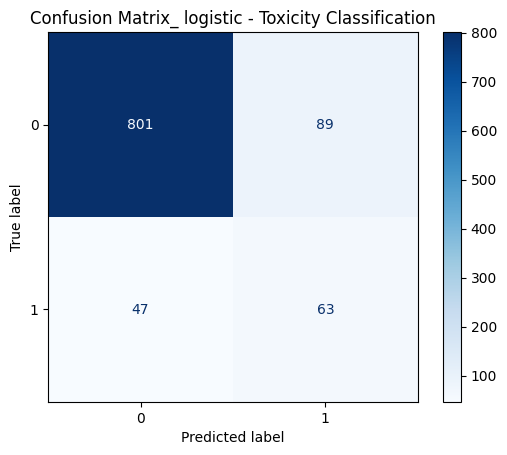

In [ ]:
# Test
X_test = test_df['Comment'].apply(preprocess)

y_test_pred_logistic_toxic = logistic_pipeline.predict(X_test)
y_test_logistic = test_df['Toxicity']
test_df['LR_Predicted_Toxicity'] = y_test_pred_logistic_toxic
print("📊 [Logistic] Toxicity Test Accuracy:", accuracy_score(test_df['Toxicity'], test_df['LR_Predicted_Toxicity']))
print(classification_report(test_df['Toxicity'], test_df['LR_Predicted_Toxicity']))

# 🧩 Ma trận nhầm lẫn
cm = confusion_matrix(y_test_logistic, y_test_pred_logistic_toxic, labels=logistic_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix_ logistic - Toxicity Classification")
plt.show()

🔎 Logistic Regression - Constructiveness:
              precision    recall  f1-score   support

           0       0.87      0.71      0.79      1271
           1       0.62      0.82      0.71       729

    accuracy                           0.75      2000
   macro avg       0.75      0.77      0.75      2000
weighted avg       0.78      0.75      0.76      2000

Accuracy: 0.7525


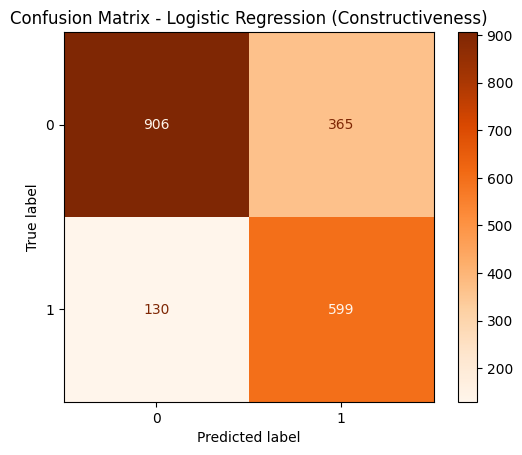

In [ ]:
# Constructiveness
logistic_pipeline.fit(X_train, y_train_constructive)
y_pred_logistic_cons = logistic_pipeline.predict(X_valid)
valid_df['predicted_logistic_constructiveness'] = y_pred_logistic_cons

print("🔎 Logistic Regression - Constructiveness:")
print(classification_report(y_valid_constructive, y_pred_logistic_cons))
print("Accuracy:", accuracy_score(y_valid_constructive, y_pred_logistic_cons))


# Tính confusion matrix
cm = confusion_matrix(y_valid_constructive, y_pred_logistic_cons, labels=logistic_pipeline.classes_)

# Hiển thị confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_pipeline.classes_)
disp.plot(cmap=plt.cm.Oranges)  # Bạn có thể đổi sang Blues hoặc Greens
plt.title("Confusion Matrix - Logistic Regression (Constructiveness)")
plt.show()


In [ ]:
# 🔍 Trích xuất mô hình và vectorizer từ pipeline
clf = logistic_pipeline.named_steps['clf']
vectorizer = logistic_pipeline.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()

# 📌 Lấy trọng số w và bias b
w = clf.coef_[0]        # Vector trọng số cho lớp Constructiveness
b = clf.intercept_[0]   # Bias (intercept)

# 📊 Tạo DataFrame hiển thị trọng số của từng từ/ngram
weights_df = pd.DataFrame({
    "Từ/ngram": feature_names,
    "Trọng số Logistic (w)": w
})

# 🔽 Sắp xếp theo độ ảnh hưởng giảm dần
weights_df_sorted = weights_df.sort_values(by="Trọng số Logistic (w)", ascending=False).reset_index(drop=True)

# 📥 In bias và bảng trọng số
print("⚖️ Bias (intercept):", b)
weights_df_sorted


⚖️ Bias (intercept): -1.4909464136334987


,Từ/ngram,Trọng số Logistic (w)
0,xe,4.386428
1,nên,3.476971
2,nhưng,3.084666
3,hơn,2.910881
4,khi,2.856141
...,...,...
96984,sao,-1.120083
96985,chúc,-1.237496
96986,mong,-1.286359
96987,thật,-1.773114


In [ ]:
# Lọc các câu bị phân loại sai
misclassified_cons_logistic = valid_df[valid_df['Constructiveness'] != valid_df['predicted_logistic_constructiveness']]

# In một số câu sai
print("📌 Tổng số câu bị phân loại sai:", len(misclassified_cons_logistic))
print("\n🔍 Một số ví dụ bị nhầm lẫn:")

for i, (index, row) in enumerate(misclassified_cons_logistic.head(20).iterrows(), 1):
    print(f"\n❌ Câu bị sai thứ {i} (dòng gốc số {row['Unnamed: 0']}):")
    print("🗣 Nội dung:", row['Comment'])
    print(" Câu sau khi xử lý:", row['processed'])
    print("✅ Nhãn thực tế:", row['Constructiveness'], "| ❌ Dự đoán:", row['predicted_logistic_constructiveness'])

📌 Tổng số câu bị phân loại sai: 495

🔍 Một số ví dụ bị nhầm lẫn:

❌ Câu bị sai thứ 1 (dòng gốc số 7218):
🗣 Nội dung: Cuộc bầu cư người đứng đầu Quốc gia ở Mỹ là công khai và công bằng nhất, chính vì vậy đến khi có kết quả chính thức mới biết được người dân họ bầu cho ai.
 Câu sau khi xử lý: cuộc bầu cư người đứng đầu quốc gia ở mỹ công khai công bằng nhất chính vì vậy khi kết quả chính thức mới biết được người dân họ bầu ai
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu bị sai thứ 2 (dòng gốc số 5360):
🗣 Nội dung: Hoan hô sự quả cảm của các chiến sĩ và sự đồng lòng của các anh em lái xe đường dài và người dân xung quanh.
 Câu sau khi xử lý: hoan hô sự quả cảm các chiến sĩ sự đồng lòng các anh em lái xe đường dài người dân xung quanh
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu bị sai thứ 3 (dòng gốc số 1397):
🗣 Nội dung: Người ở vị trí cuối cùng có lợi thế hơn những người còn lại.
 Câu sau khi xử lý: người ở vị trí cuối cùng lợi thế hơn những người còn lại
✅ Nhãn thực tế: 0 | ❌ Dự đoán: 1

❌ Câu b

In [ ]:
get_tfidf_and_contributions_logistic(
    pipeline=logistic_pipeline,
    df=valid_df,
    text_column='processed',
    row_id=3885,
    id_column='Unnamed: 0',
    target_column='Constructiveness',
    pred_column='predicted_logistic_constructiveness'
)

📝 Văn bản gốc: Tại sao các nước không học tập cách chống dịch lẫn nhau nhỉ, Việt Nam và Trung Quốc là một ví dụ.
🔧 Văn bản đã xử lý: tại sao các nước không học tập cách chống dịch lẫn nhau nhỉ việt nam trung quốc một ví dụ
✅ Nhãn thực tế: 1 | ❌ Nhãn dự đoán: 0
⚖️  Bias (intercept): -1.4909
🎯 Xác suất dự đoán nhãn 1 (sigmoid): 0.3584



,Từ/ngram,Trọng số TF-IDF,Trọng số Logistic (w),Đóng góp (TF-IDF × w)
0,nhau,0.133473,1.088361,0.145267
1,các,0.081209,1.749265,0.142055
2,tập,0.136530,1.003104,0.136954
3,dịch,0.127925,1.009670,0.129162
4,tại,0.124505,0.928822,0.115643
5,nước,0.108022,1.049975,0.113421
6,không,0.060796,1.814805,0.110333
7,cách,0.116294,0.815165,0.094799
8,dụ,0.174752,0.442712,0.077365
9,ví,0.177064,0.434944,0.077013


📊 [Logistic] Constructiveness Test Accuracy: 0.779
              precision    recall  f1-score   support

           0       0.92      0.72      0.80       636
           1       0.64      0.89      0.75       364

    accuracy                           0.78      1000
   macro avg       0.78      0.80      0.78      1000
weighted avg       0.82      0.78      0.78      1000



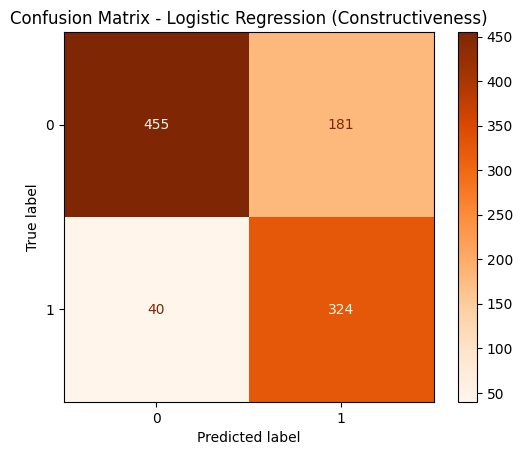

In [ ]:
# Test
y_test_pred_logistic_cons = logistic_pipeline.predict(X_test)
y_test_constructive = test_df['Constructiveness']
test_df['LR_Predicted_Constructiveness'] = y_test_pred_logistic_cons
print("📊 [Logistic] Constructiveness Test Accuracy:", accuracy_score(test_df['Constructiveness'], test_df['LR_Predicted_Constructiveness']))
print(classification_report(test_df['Constructiveness'], test_df['LR_Predicted_Constructiveness']))

# Tính confusion matrix
cm = confusion_matrix(y_test_constructive, y_test_pred_logistic_cons, labels=logistic_pipeline.classes_)

# Hiển thị confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_pipeline.classes_)
disp.plot(cmap=plt.cm.Oranges)  # Bạn có thể đổi sang Blues hoặc Greens
plt.title("Confusion Matrix - Logistic Regression (Constructiveness)")
plt.show()

# MỞ RỘNG SỬ DỤNG BERT (một mô hình phi tuyến (non-linear model))


Trong quá trình xây dựng hệ thống phân loại văn bản tiếng Việt, nhóm nhận thấy rằng việc hiểu chính xác ngữ nghĩa và bối cảnh của từng câu là yếu tố then chốt để xác định các nhãn như Toxicity hay Constructiveness. Do đó, nhóm lựa chọn sử dụng PhoBERT – một biến thể của mô hình BERT được huấn luyện đặc biệt trên dữ liệu tiếng Việt, nhằm khai thác tối đa khả năng học ngữ nghĩa và ngữ cảnh hai chiều.

Khác với các mô hình truyền thống như SVM hay Logistic Regression vốn chỉ dựa vào tần suất từ vựng (n-gram, TF-IDF) và không hiểu được ngữ cảnh sâu xa trong câu, PhoBERT có thể nắm bắt mối quan hệ giữa các từ trong toàn bộ câu theo cả hai chiều trái–phải, từ đó hiểu rõ ý định người viết, đặc biệt trong các trường hợp sử dụng từ ngữ mỉa mai, bóng gió hoặc đa nghĩa – những đặc điểm rất phổ biến trong dữ liệu tiếng Việt thực tế.

Thêm vào đó, PhoBERT cho phép rút gọn đáng kể quá trình tiền xử lý như loại bỏ từ dừng, chuẩn hoá, hoặc tách từ thủ công – vốn là những bước bắt buộc khi dùng các mô hình truyền thống. Với PhoBERT, ta có thể đưa trực tiếp văn bản gốc vào tokenizer và trích xuất đặc trưng ngữ nghĩa mạnh mẽ hơn thông qua embedding được học sẵn.

In [ ]:
!pip install -q underthesea transformers
!pip install torch

In [2]:
from underthesea import word_tokenize

def segment(text):
    return ' '.join(word_tokenize(str(text), format="text"))


In [3]:
import pandas as pd

# Đọc dữ liệu
train_df = pd.read_csv("/content/ViCTSD_train.csv")
valid_df = pd.read_csv("/content/ViCTSD_valid.csv")
test_df  = pd.read_csv("/content/ViCTSD_test.csv")

# Tách từ cho PhoBERT
for df in [train_df, valid_df, test_df]:
    df['processed_bert'] = df['Comment'].apply(segment)



In [4]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 128
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)

class ViCTSDDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding='max_length',
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels.values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
from transformers import AutoModel
import torch.nn as nn

class PhoBERTClassifier(nn.Module):
    def __init__(self):
        super(PhoBERTClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(768, 2)  # nhị phân

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = output.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls))


In [6]:
def print_wrong_predictions(label_name, model):
    print(f"\n🟨 Dự đoán sai cho nhãn: {label_name}")

    dataset = ViCTSDDataset(valid_df['processed_bert'], valid_df[label_name])
    model.eval()
    wrong_samples = []

    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]
            input_id = sample['input_ids'].unsqueeze(0).to(device)
            attn_mask = sample['attention_mask'].unsqueeze(0).to(device)
            true_label = sample['labels'].item()

            output = model(input_id, attn_mask)
            pred_label = torch.argmax(output, dim=1).item()

            if pred_label != true_label:
                comment_text = valid_df.iloc[i]['Comment']
                wrong_samples.append((comment_text, true_label, pred_label))

    print(f"🔴 Tổng số câu sai: {len(wrong_samples)}")
    for idx, (text, true_lbl, pred_lbl) in enumerate(wrong_samples[:30]):
        print(f"\n[{idx+1}] ❌ {text}")
        print(f"   → Thực tế: {true_lbl} | Dự đoán: {pred_lbl}")


In [7]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=["Không", label_name])
    return f1, report


## Toxicity

In [8]:
label_name = "Toxicity"

train_dataset = ViCTSDDataset(train_df['processed_bert'], train_df[label_name])
valid_dataset = ViCTSDDataset(valid_df['processed_bert'], valid_df[label_name])
test_dataset  = ViCTSDDataset(test_df['processed_bert'],  test_df[label_name])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)


In [ ]:
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import classification_report, f1_score

# Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Gán nhãn nếu chưa có
# label_name = "Toxicity"  # hoặc "Constructiveness"

# Tính trọng số lớp (0/1) để xử lý mất cân bằng
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df[label_name]),
    y=train_df[label_name]
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

#  Khởi tạo mô hình
model = PhoBERTClassifier().to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)


#  Biến theo dõi mô hình tốt nhất
best_f1 = 0.0
best_model_path = f"best_model_{label_name}.pt"

# Vòng huấn luyện chính
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\n[Epoch {epoch+1}] Train Loss: {total_loss / len(train_loader):.4f}")

    # 🎯 Đánh giá trên VALID
    f1_val, report_val = evaluate(model, valid_loader)
    print(f"[Epoch {epoch+1}] Validation F1-score: {f1_val:.4f}")
    print(report_val)

    # ✅ Lưu mô hình nếu tốt hơn
    if f1_val > best_f1:
        best_f1 = f1_val
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Đã lưu mô hình tốt nhất với F1 = {f1_val:.4f}")


Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 438/438 [02:40<00:00,  2.73it/s]



[Epoch 1] Train Loss: 0.6901


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[Epoch 1] Validation F1-score: 0.0000
              precision    recall  f1-score   support

       Không       0.88      1.00      0.94      1768
    Toxicity       0.00      0.00      0.00       232

    accuracy                           0.88      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.78      0.88      0.83      2000



100%|██████████| 438/438 [02:39<00:00,  2.75it/s]


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[Epoch 9] Validation F1-score: 0.0000
              precision    recall  f1-score   support

       Không       0.88      1.00      0.94      1768
    Toxicity       0.00      0.00      0.00       232

    accuracy                           0.88      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.78      0.88      0.83      2000



100%|██████████| 438/438 [02:38<00:00,  2.76it/s]



[Epoch 10] Train Loss: 0.6856
[Epoch 10] Validation F1-score: 0.0000
              precision    recall  f1-score   support

       Không       0.88      1.00      0.94      1768
    Toxicity       0.00      0.00      0.00       232

    accuracy                           0.88      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.78      0.88      0.83      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
print_wrong_predictions("Toxicity", model)


🟨 Dự đoán sai cho nhãn: Toxicity
🔴 Tổng số câu sai: 232

[1] ❌ Tội như thế này làm hại đến sức khỏe tính mạng con người ,phải có chế tài đủ mạnh để xử lý. Công ty làm phải có trách nhiệm sản phẩm mình làm ra , cứ làm bừa không kiểm soát được chất lượng sản phẩm rồi tung ra thị trường bán cho dân là không thể chấp nhận được
   → Thực tế: 1 | Dự đoán: 0

[2] ❌ Mình ko hiểu đc đó lại là bánh trung thu
   → Thực tế: 1 | Dự đoán: 0

[3] ❌ Hổ dữ không ăn thịt con. Ông này có còn là con người không?
   → Thực tế: 1 | Dự đoán: 0

[4] ❌ Tôi nghĩ rằng, ở tuổi các cháu" mỗi ngày đến trường là một ngày vui", còn cách ông Thái Văn Tài nói ở đây là mục đích giúp các em đọc thông viết thạo sớm, thưa với ông rằng là đến thời điểm hiện tại, tỉ lệ mù chữ nước ta là rất ít, và cũng ít có cháu nào mà hết lớp 1 còn mù con chữ lắm. Chúng tôi cần là các cháu đi học vui vẻ, ngày càng có tư duy logic, thể chất và tri thức hài hòa. Còn ơ

In [11]:
from sklearn.metrics import classification_report, accuracy_score

# ✅ Nạp lại mô hình tốt nhất
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"== Đánh giá nhãn {label_name} ==")
print(classification_report(all_labels, all_preds, target_names=["Không", label_name]))
acc = accuracy_score(all_labels, all_preds)
print(f"🎯 Độ chính xác: {acc:.5f}")

== Đánh giá nhãn Toxicity ==
              precision    recall  f1-score   support

       Không       0.91      0.82      0.87       890
    Toxicity       0.20      0.36      0.26       110

    accuracy                           0.77      1000
   macro avg       0.56      0.59      0.56      1000
weighted avg       0.83      0.77      0.80      1000

🎯 Độ chính xác: 0.77300


<Figure size 500x400 with 0 Axes>

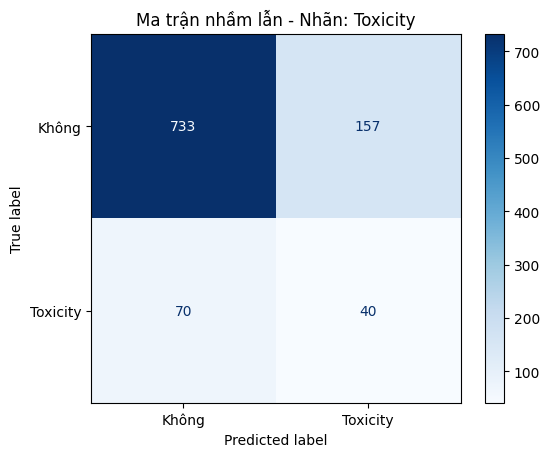

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tính confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Không", label_name])

# Vẽ ma trận
plt.figure(figsize=(5, 4))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Ma trận nhầm lẫn - Nhãn: {label_name}")
plt.show()


## Constructiveness

In [13]:

label_name = "Constructiveness"

train_dataset = ViCTSDDataset(train_df['processed_bert'], train_df[label_name])
valid_dataset = ViCTSDDataset(valid_df['processed_bert'], valid_df[label_name])
test_dataset  = ViCTSDDataset(test_df['processed_bert'],  test_df[label_name])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)


In [ ]:
#  Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#  Tính trọng số lớp (0/1) để xử lý mất cân bằng
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df[label_name]),
    y=train_df[label_name]
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

#  Khởi tạo mô hình
model = PhoBERTClassifier().to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)


#  Biến theo dõi mô hình tốt nhất
best_f1 = 0.0
best_model_path = f"best_model_{label_name}.pt"

#  Vòng huấn luyện chính
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\n[Epoch {epoch+1}] Train Loss: {total_loss / len(train_loader):.4f}")

    # 🎯 Đánh giá trên VALID
    f1_val, report_val = evaluate(model, valid_loader)
    print(f"[Epoch {epoch+1}] Validation F1-score: {f1_val:.4f}")
    print(report_val)

    # ✅ Lưu mô hình nếu tốt hơn
    if f1_val > best_f1:
        best_f1 = f1_val
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Đã lưu mô hình tốt nhất với F1 = {f1_val:.4f}")


Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 438/438 [02:39<00:00,  2.75it/s]



[Epoch 1] Train Loss: 0.5129
[Epoch 1] Validation F1-score: 0.7249
                  precision    recall  f1-score   support

           Không       0.87      0.76      0.81      1271
Constructiveness       0.66      0.80      0.72       729

        accuracy                           0.78      2000
       macro avg       0.77      0.78      0.77      2000
    weighted avg       0.79      0.78      0.78      2000

✅ Đã lưu mô hình tốt nhất với F1 = 0.7249


100%|██████████| 438/438 [02:39<00:00,  2.74it/s]



[Epoch 2] Train Loss: 0.4833
[Epoch 2] Validation F1-score: 0.7256
                  precision    recall  f1-score   support

           Không       0.89      0.72      0.80      1271
Constructiveness       0.64      0.84      0.73       729

        accuracy                           0.77      2000
       macro avg       0.76      0.78      0.76      2000
    weighted avg       0.80      0.77      0.77      2000

✅ Đã lưu mô hình tốt nhất với F1 = 0.7256


100%|██████████| 438/438 [02:39<00:00,  2.75it/s]


...


[Epoch 8] Train Loss: 0.5340
[Epoch 8] Validation F1-score: 0.7276
                  precision    recall  f1-score   support

           Không       0.86      0.80      0.83      1271
Constructiveness       0.69      0.77      0.73       729

        accuracy                           0.79      2000
       macro avg       0.77      0.79      0.78      2000
    weighted avg       0.80      0.79      0.79      2000

✅ Đã lưu mô hình tốt nhất với F1 = 0.7276


100%|██████████| 438/438 [02:39<00:00,  2.75it/s]



[Epoch 9] Train Loss: 0.4577
[Epoch 9] Validation F1-score: 0.7376
                  precision    recall  f1-score   support

           Không       0.86      0.81      0.84      1271
Constructiveness       0.70      0.78      0.74       729

        accuracy                           0.80      2000
       macro avg       0.78      0.79      0.79      2000
    weighted avg       0.80      0.80      0.80      2000

✅ Đã lưu mô hình tốt nhất với F1 = 0.7376


100%|██████████| 438/438 [02:39<00:00,  2.74it/s]



[Epoch 10] Train Loss: 0.4322
[Epoch 10] Validation F1-score: 0.7224
                  precision    recall  f1-score   support

           Không       0.90      0.70      0.79      1271
Constructiveness       0.62      0.86      0.72       729

        accuracy                           0.76      2000
       macro avg       0.76      0.78      0.76      2000
    weighted avg       0.80      0.76      0.76      2000



In [15]:
print_wrong_predictions("Constructiveness", model)


🟨 Dự đoán sai cho nhãn: Constructiveness
🔴 Tổng số câu sai: 481

[1] ❌ Cuộc bầu cư người đứng đầu Quốc gia ở Mỹ là công khai và công bằng nhất, chính vì vậy đến khi có kết quả chính thức mới biết được người dân họ bầu cho ai.
   → Thực tế: 0 | Dự đoán: 1

[2] ❌ Hoan hô sự quả cảm của các chiến sĩ và sự đồng lòng của các anh em lái xe đường dài và người dân xung quanh.
   → Thực tế: 0 | Dự đoán: 1

[3] ❌ Tôi cực lực phản đối cho hs dùng đt trong lớp học vì tôi là một giáo viên nên tôi biết hs có thực sự cần hay không?
   → Thực tế: 0 | Dự đoán: 1

[4] ❌ Giải Nobel hoà bình nên được trao cho tất cả các y bác sĩ trên toàn thế giới vì sự cống hiến quên mình vì sức khoẻ của toàn nhân loại
   → Thực tế: 0 | Dự đoán: 1

[5] ❌ Nếu nạn nhân côn đồ không chết, khả năng cao là anh ta sẽ còn quay trở lại, và khi đó thì chắc là đạn sẽ không lép. Trường hợp này nên được giảm án.  
   → Thực tế: 0 | Dự đoán: 1

[6] ❌ A di đà phật! Tội nghiệp quá! Cha mẹ các em đâu? Có tình cờ xem VnExpress không?
  

In [16]:
# ✅ Nạp lại mô hình tốt nhất
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"== Đánh giá nhãn {label_name} ==")
print(classification_report(all_labels, all_preds, target_names=["Không", label_name]))

acc = accuracy_score(all_labels, all_preds)
print(f"🎯 Độ chính xác: {acc:.5f}")

== Đánh giá nhãn Constructiveness ==
                  precision    recall  f1-score   support

           Không       0.85      0.79      0.82       636
Constructiveness       0.67      0.76      0.72       364

        accuracy                           0.78      1000
       macro avg       0.76      0.78      0.77      1000
    weighted avg       0.79      0.78      0.78      1000

🎯 Độ chính xác: 0.77900


<Figure size 500x400 with 0 Axes>

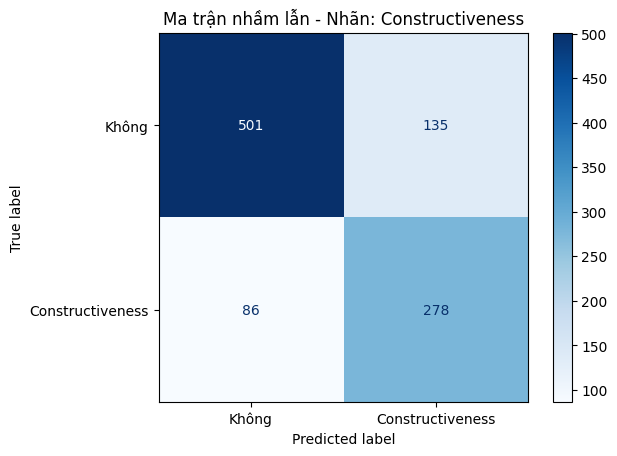

In [17]:
# Tính confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Không", label_name])

# Vẽ ma trận
plt.figure(figsize=(5, 4))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Ma trận nhầm lẫn - Nhãn: {label_name}")
plt.show()
